# Forecasting the Operating Results of U.S. Publicly Traded Companies

# Introduction

## Research Objective

Assessing the financial health of companies has long been a cornerstone of investment analysis, banking, and risk management. In an era of widespread access to digital quarterly reports, the challenge is no longer a lack of data, but rather the ability to efficiently identify the signals that truly distinguish profitable companies from those heading toward losses. Although financial theory has relied on traditional ratios for decades, in the real economy, the relationships between assets, debt levels, and margins are complex and nonlinear.

The goal of my project is: **"to predict whether a company will generate an operating profit or a loss based on liquidity, debt, and efficiency ratios".**

Basing the analysis on operating result rather than net income filters out one-time events, tax shields, and financial transactions. The model evaluates only the business’s actual operational efficiency. In other words, it assesses whether a given company is capable of generating a profit or a loss solely from its core business operations.

I have a degree in economics, currently work as an accountant, and spend my free time investing in the stock market. My goal in choosing this project topic was to use my knowledge of economics, finance, and the stock market to conduct an in-depth analysis of the chosen topic and examine it from various perspectives.

## Data Description

The data for this project comes from the official U.S. government website - Electronic Data Gathering, Analysis, and Retrieval (SEC EDGAR) website and pertains to the publication of raw financial data from the quarterly reports of companies listed on U.S. stock exchanges. The scope of the study covers the period from the first quarter of 2025 to the first quarter of 2026. 

Source: www.sec.gov/data-research/sec-markets-data/financial-statement-data-sets

**United States Securities and Exchange Commission (SEC)** - serves as the primary regulator and overseer of the U.S. financial market. It acts as both a “policeman” and a "judge" on the stock market. It ensures that companies play by the rules, do not hide their debts, and do not mislead investors.

**Electronic Data Gathering, Analysis, and Retrieval (SEC EDGAR)** - a large online database managed directly by the SEC. It works like a digital library. This is where publicly traded companies upload their official reports.

**Explanation of the columns:**

**Identification Data and Metadata:**

**adsh (Accession Number)** - The unique identification number for a financial statement in the U.S. regulatory system.

**name** - The company's full registered name (e.g., Apple Inc., Microsoft Corp.).

**sic (Standard Industrial Classification)** - Industry code, it allows a company to be classified under a specific economic sector (e.g., software development, food industry).

**form** - The type of financial report filed. Most often, this is a quarterly report (10-Q) or an annual report (10-K).

**Company Assets (What does the company own?):**

**Assets (Total Assets)** - The total value of everything owned by the company. Assets include real estate, machinery, and patents, as well as inventory and cash on hand.

**AssetsCurrent** - Current assets, which are resources that a company can easily convert into cash within the next year (e.g., merchandise ready for sale, outstanding customer invoices).

**CashAndCashEquivalentsAtCarryingValue** - The most liquid assets. Cash in bank accounts and very safe, short-term investments that can be converted to cash overnight.

**Debts and Liabilities (What Does the Company Owe?):**

**Liabilities** - The total of all the company's debts and liabilities. This includes bank loans, bonds issued, and unpaid bills.

**LiabilitiesCurrent** - Debts and bills that the company must absolutely pay off within the next 12 months (e.g., upcoming loan payments, invoices from suppliers, employee salaries, or taxes).

**Financial Results and Value (How Is the Company Performing?):**

**Revenues** - The total amount of money paid by customers for the products or services they purchased. This is the “gross” amount before deducting any business operating costs.

**OperatingIncomeLoss (This is the column I focused on in the project)** - **The money remaining from revenue after paying direct business operating costs (e.g., materials, salaries, office rent), but before paying taxes and interest on loans. It shows whether the company’s core business is profitable.**

**NetIncomeLoss** - The final financial result, or “net” profit. The amount remaining to the company after deducting literally all costs, expenses, interest, and taxes. A positive value indicates a profit, while a negative value indicates a loss.

**StockholdersEquity** - The book value of a company belonging to its owners (shareholders). It is calculated by subtracting all liabilities from total assets. It indicates how much money would remain for the owners if the company sold all its assets and paid off all its debts.

# Importing Data from CSV, Merging Data and Performing Preliminary Data Cleaning 

## Importing and Installing Libraries

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
import shap

## Data Merging

I have selected the raw financial data that I will need later in the project to calculate financial ratios.

In [4]:
selected_tags = ['Assets',
                'Liabilities',
                'NetIncomeLoss',
                'Revenues',
                'RevenueFromContractWithCustomerExcludingAssessedTax',
                'SalesRevenueNet',
                'StockholdersEquity',
                'RetainedEarnings',
                'OperatingIncomeLoss',
                'CashAndCashEquivalentsAtCarryingValue',
                'AssetsCurrent',
                'LiabilitiesCurrent'
                ]

I created a variable called “folders” that contains the names of the folders where my data is stored.

In [5]:
folders = ['1Q2025', '2Q2025', '3Q2025', '4Q2025', '1Q2026']

I created loops to read files from each folder.

In [6]:
tables_list = []

for folder in folders:
    # 1. Loaded a file containing company data
    sub = pd.read_csv(f"{folder}/sub.txt", sep='\t', low_memory=False)

    # I selected only the main reports
    sub = sub[sub['form'].isin(['10-Q', '10-K'])]

    # I kept only 4 useful columns
    sub = sub[['adsh', 'name', 'sic', 'form']]

    # 2 Loaded a file containing numbers
    num = pd.read_csv(f"{folder}/num.txt", sep='\t', low_memory=False)

    # I chose only four financial ratios
    num = num[num['tag'].isin(selected_tags)]

    # I kept only 3 useful columns
    num = num[['adsh', 'tag', 'value']]

    # 3. I combined the company data to its financial figures (by the ‘adsh’ code)
    merged_df = pd.merge(sub, num, on='adsh')

    # I added a column showing which quarter it's from
    merged_df['quarter'] = folder
    tables_list.append(merged_df)

I combined 5 quarters into a single df.

In [7]:
final_df = pd.concat(tables_list, ignore_index=True)

In [8]:
final_df.head()

,adsh,name,sic,form,tag,value,quarter
0,0000015615-25-000021,MASTEC INC,1623.0,10-K,Revenues,3.000000e+05,1Q2025
1,0000015615-25-000021,MASTEC INC,1623.0,10-K,NetIncomeLoss,1.627880e+08,1Q2025
2,0000015615-25-000021,MASTEC INC,1623.0,10-K,Revenues,2.072800e+09,1Q2025
3,0000015615-25-000021,MASTEC INC,1623.0,10-K,LiabilitiesCurrent,2.999699e+09,1Q2025
4,0000015615-25-000021,MASTEC INC,1623.0,10-K,Revenues,3.962000e+09,1Q2025


I changed the table orientation from vertical to **horizontal**. This allowed me to perform further transformations and build the target DataFrame.

In [9]:
wide_df = final_df.pivot_table(
    index=['adsh', 'name', 'sic', 'form', 'quarter'],  # Column identifiers (remain unchanged)
    columns='tag',                                    # The values in this column will become the new headers
    values='value',                                   # Numbers to fill in the table
    aggfunc='first'                                   # In the case of duplicates, it takes the first value it encounters
).reset_index()

# I removed the column index name to make the table easier to read
wide_df.columns.name = None

wide_df.head()

,adsh,name,sic,form,quarter,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,Liabilities,LiabilitiesCurrent,NetIncomeLoss,OperatingIncomeLoss,RetainedEarnings,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,StockholdersEquity
0,0000002488-25-000012,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2025,6.788500e+10,1.676800e+10,3.933000e+09,NaN,6.689000e+09,1.320000e+09,4.010000e+08,NaN,1.380000e+09,NaN,-1.310000e+08
1,0000002488-25-000047,ADVANCED MICRO DEVICES INC,3674.0,10-Q,2Q2025,7.155000e+10,2.159500e+10,6.049000e+09,NaN,7.703000e+09,7.090000e+08,-1.084000e+09,NaN,3.674000e+09,NaN,-2.800000e+07
2,0000002488-25-000108,ADVANCED MICRO DEVICES INC,3674.0,10-Q,3Q2025,6.922600e+10,2.451900e+10,4.442000e+09,NaN,7.281000e+09,2.650000e+08,1.660000e+08,NaN,1.707000e+09,NaN,1.700000e+07
3,0000002488-25-000166,ADVANCED MICRO DEVICES INC,3674.0,10-Q,4Q2025,6.922600e+10,1.904900e+10,3.787000e+09,NaN,7.281000e+09,7.710000e+08,7.240000e+08,NaN,6.819000e+09,NaN,-1.000000e+07
4,0000002488-26-000018,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2026,6.922600e+10,1.904900e+10,3.933000e+09,NaN,7.281000e+09,1.641000e+09,1.187000e+09,NaN,1.086300e+10,NaN,-3.099000e+09


I created a new column **'revenues_total'** and filled in the missing values in the revenue column with values from another tag. Some companies report their revenue to the SEC under different tags.

In [10]:
wide_df['revenues_total'] = (
    wide_df['Revenues']
    .fillna(wide_df['RevenueFromContractWithCustomerExcludingAssessedTax'])
)

In [11]:
print(f'Number of rows: {len(wide_df)}')

Number of rows: 26644


I checked for missing values in each column.

In [12]:
print('Number of missing values in columns:')
print(wide_df.isnull().sum())

Number of missing values in columns:
adsh                                                       0
name                                                       0
sic                                                        0
form                                                       0
quarter                                                    0
Assets                                                   130
AssetsCurrent                                           5467
CashAndCashEquivalentsAtCarryingValue                   6223
Liabilities                                             3177
LiabilitiesCurrent                                      5561
NetIncomeLoss                                           1541
OperatingIncomeLoss                                     5822
RetainedEarnings                                       26637
RevenueFromContractWithCustomerExcludingAssessedTax    14904
Revenues                                               18076
StockholdersEquity                              

A large number of missing values were noted in the **'revenues_total'** column. This is because the remaining companies—such as banks—report only interest income, not their total revenue.

In [13]:
wide_df.head()

,adsh,name,sic,form,quarter,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,Liabilities,LiabilitiesCurrent,NetIncomeLoss,OperatingIncomeLoss,RetainedEarnings,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,StockholdersEquity,revenues_total
0,0000002488-25-000012,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2025,6.788500e+10,1.676800e+10,3.933000e+09,NaN,6.689000e+09,1.320000e+09,4.010000e+08,NaN,1.380000e+09,NaN,-1.310000e+08,1.380000e+09
1,0000002488-25-000047,ADVANCED MICRO DEVICES INC,3674.0,10-Q,2Q2025,7.155000e+10,2.159500e+10,6.049000e+09,NaN,7.703000e+09,7.090000e+08,-1.084000e+09,NaN,3.674000e+09,NaN,-2.800000e+07,3.674000e+09
2,0000002488-25-000108,ADVANCED MICRO DEVICES INC,3674.0,10-Q,3Q2025,6.922600e+10,2.451900e+10,4.442000e+09,NaN,7.281000e+09,2.650000e+08,1.660000e+08,NaN,1.707000e+09,NaN,1.700000e+07,1.707000e+09
3,0000002488-25-000166,ADVANCED MICRO DEVICES INC,3674.0,10-Q,4Q2025,6.922600e+10,1.904900e+10,3.787000e+09,NaN,7.281000e+09,7.710000e+08,7.240000e+08,NaN,6.819000e+09,NaN,-1.000000e+07,6.819000e+09
4,0000002488-26-000018,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2026,6.922600e+10,1.904900e+10,3.933000e+09,NaN,7.281000e+09,1.641000e+09,1.187000e+09,NaN,1.086300e+10,NaN,-3.099000e+09,1.086300e+10


I removed the nearly empty “RetainedEarnings” column and unnecessary raw revenue tags.

In [14]:
df_clean = wide_df.drop(columns=[
    'RetainedEarnings', 
    'Revenues', 
    'RevenueFromContractWithCustomerExcludingAssessedTax'
]).copy()

In [15]:
df_clean.head()

,adsh,name,sic,form,quarter,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,Liabilities,LiabilitiesCurrent,NetIncomeLoss,OperatingIncomeLoss,StockholdersEquity,revenues_total
0,0000002488-25-000012,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2025,6.788500e+10,1.676800e+10,3.933000e+09,NaN,6.689000e+09,1.320000e+09,4.010000e+08,-1.310000e+08,1.380000e+09
1,0000002488-25-000047,ADVANCED MICRO DEVICES INC,3674.0,10-Q,2Q2025,7.155000e+10,2.159500e+10,6.049000e+09,NaN,7.703000e+09,7.090000e+08,-1.084000e+09,-2.800000e+07,3.674000e+09
2,0000002488-25-000108,ADVANCED MICRO DEVICES INC,3674.0,10-Q,3Q2025,6.922600e+10,2.451900e+10,4.442000e+09,NaN,7.281000e+09,2.650000e+08,1.660000e+08,1.700000e+07,1.707000e+09
3,0000002488-25-000166,ADVANCED MICRO DEVICES INC,3674.0,10-Q,4Q2025,6.922600e+10,1.904900e+10,3.787000e+09,NaN,7.281000e+09,7.710000e+08,7.240000e+08,-1.000000e+07,6.819000e+09
4,0000002488-26-000018,ADVANCED MICRO DEVICES INC,3674.0,10-K,1Q2026,6.922600e+10,1.904900e+10,3.933000e+09,NaN,7.281000e+09,1.641000e+09,1.187000e+09,-3.099000e+09,1.086300e+10


I removed rows that do not have basic balance sheet values.

In [16]:
core_cols = ['Assets', 'Liabilities', 'NetIncomeLoss', 'StockholdersEquity']
df_clean = df_clean.dropna(subset=core_cols)

In [17]:
df_clean.head()

,adsh,name,sic,form,quarter,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,Liabilities,LiabilitiesCurrent,NetIncomeLoss,OperatingIncomeLoss,StockholdersEquity,revenues_total
5,0000002969-25-000013,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-Q,1Q2025,5.692400e+09,1.964000e+08,3.450000e+07,2.090090e+10,3.620000e+08,-1.100000e+07,1.865000e+08,1.703650e+10,0.000000e+00
6,0000002969-25-000027,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-Q,2Q2025,5.849200e+09,6.363000e+09,2.979700e+09,3.473400e+09,5.210600e+09,7.400000e+06,2.036000e+08,1.470340e+10,0.000000e+00
7,0000002969-25-000044,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-Q,3Q2025,7.436500e+09,2.134000e+08,3.840000e+07,2.090090e+10,3.671000e+08,1.878300e+09,2.252000e+08,1.703650e+10,0.000000e+00
8,0000002969-25-000055,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-K,4Q2025,3.957460e+10,6.363000e+09,2.979700e+09,2.090090e+10,4.179600e+09,2.300200e+09,2.494600e+09,1.703650e+10,1.260000e+10
9,0000002969-26-000008,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-Q,1Q2026,6.916800e+09,1.693000e+08,4.030000e+07,5.304800e+09,2.269000e+08,-1.100000e+07,3.882000e+08,1.541130e+10,8.171000e+08


I removed rows with missing values in the other indicators needed for further analysis. Because in order to calculate the fundamental analysis metrics for companies, I cannot have any missing values.

In [18]:
additional_cols = [
    'revenues_total', 
    'OperatingIncomeLoss', 
    'AssetsCurrent', 
    'LiabilitiesCurrent', 
    'CashAndCashEquivalentsAtCarryingValue'
]
df_clean = df_clean.dropna(subset=additional_cols)

I made sure there were no missing values or duplicates in my DataFrame.

In [19]:
print(f"Number of rows before clearing: {len(wide_df)}")
print(f"Number of rows after cleaning: {len(df_clean)}")
print(f"Number of duplicates: {df_clean.duplicated().sum()}")
print("\nNumber of missing values in the new table df_clean:")
print(df_clean.info())

Number of rows before clearing: 26644
Number of rows after cleaning: 9850
Number of duplicates: 0

Number of missing values in the new table df_clean:
<class 'pandas.core.frame.DataFrame'>
Index: 9850 entries, 5 to 26642
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   adsh                                   9850 non-null   object 
 1   name                                   9850 non-null   object 
 2   sic                                    9850 non-null   float64
 3   form                                   9850 non-null   object 
 4   quarter                                9850 non-null   object 
 5   Assets                                 9850 non-null   float64
 6   AssetsCurrent                          9850 non-null   float64
 7   CashAndCashEquivalentsAtCarryingValue  9850 non-null   float64
 8   Liabilities                            9850 non-null   float6

# Calculation of Financial Ratios

Based on raw financial data, I calculated the fundamental analysis ratios commonly used to compare publicly traded companies.

In [20]:
df_features = df_clean.copy()

**ROA (Return of Assets)** - It is a return on assets ratio that indicates how effectively a company uses its assets to generate revenue.

It shows how many dollars in profit a company can generate from every dollar of assets it owns (machinery, buildings, equipment). The higher the value, the more efficiently the company’s assets “pay for themselves.”

In [21]:
df_features['ROA'] = df_features['NetIncomeLoss'] / df_features['Assets']

**ROE (Return on Equity)** - Ratio allows for an assessment of the effectiveness of a company's use of equity.

It measures how effectively the money invested in a company directly by its owners (shareholders) is working. It tells an investor how much profit each of their own dollars generates for them.

In [22]:
df_features['ROE'] = df_features['NetIncomeLoss'] / df_features['StockholdersEquity']

**Operating Margin** - A profitability ratio that indicates what percentage of sales revenue is represented by operating profit before taxes and interest.

It shows how many cents of every dollar in sales remain in the company's pocket after covering daily business expenses (salaries, supplies, office rent), but before paying taxes and loan payments.

In [23]:
df_features['operating_margin'] = df_features['OperatingIncomeLoss'] / df_features['revenues_total']

**Net Margin** - It is a financial ratio that shows what percentage of a company's revenue remains as net profit after deducting all costs, taxes, and interest.

It shows how much “net” profit the company is left with from sales after paying literally all bills, interest on debt, and taxes. This is the ultimate test of whether the business is profitable.

In [24]:
df_features['net_margin'] = df_features['NetIncomeLoss'] / df_features['revenues_total']

**Current Ratio** - A financial measure that indicates a company's ability to pay off its short-term debts. It is calculated by dividing current assets by current liabilities. A standard, safe value for this ratio is typically between 1.2 and 2.0.

It checks whether the company has enough assets “on hand” (cash, inventory) to easily pay its bills and debts due within the next year. A score below 1.0 is a warning that the company may run out of money to cover its ongoing expenses.

In [25]:
df_features['current_ratio'] = df_features['AssetsCurrent'] / df_features['LiabilitiesCurrent']

**Debt to Equity (D/E)** - A financial metric that compares a company’s total liabilities to its shareholder equity.

It compares a company's debt to the money owned by its shareholders. It indicates whether the company is expanding primarily with its own funds or with borrowed money.

In [26]:
df_features['debt_to_equity'] = df_features['Liabilities'] / df_features['StockholdersEquity']

**Debt Ratio** - A financial metric that compares a company's total liabilities to its total assets to show what percentage of its resources are funded by borrowing.

It shows what portion of the company's total assets was purchased with borrowed money. A value of 0.6 means that 60% of the company's assets are actually financed by debt.

In [27]:
df_features['debt_ratio'] = df_features['Liabilities'] / df_features['Assets']

**Asset Turnover Ratio** - measures how well a company uses its assets to make sales, calculated as net sales divided by average total assets.

It shows how quickly a company's assets are “converted” into sales revenue. It indicates whether machinery and factories are sitting idle or operating at full capacity and quickly generating new payments from customers.

In [28]:
df_features['asset_turnover'] = df_features['revenues_total'] / df_features['Assets']

**Cash Ratio** - measures a company's ability to cover its short-term debt using only cash and cash equivalents.

The most rigorous financial test. It shows whether a company would be able to pay off its immediate debts right away, using only the cash in its bank account, without having to sell any of its assets.

In [29]:
df_features['cash_ratio'] = df_features['CashAndCashEquivalentsAtCarryingValue'] / df_features['LiabilitiesCurrent']

**Working Capital to Assets Ratio** - measures a company's net liquid assets relative to its overall asset base.

It indicates what portion of the company's assets constitutes a financial cushion for day-to-day operating expenses. A higher ratio means that the company maintains a safe reserve of assets in case of unforeseen downtime.

In [30]:
df_features['working_capital_to_assets'] = (df_features['AssetsCurrent'] - df_features['LiabilitiesCurrent']) / df_features['Assets']

I converted infinite values (inf, -inf) to NaN.

In [31]:
df_features = df_features.replace([np.inf, -np.inf], np.nan)

I removed the rows that had infinite values in the calculated metrics.

In [32]:
ratio_cols = ['ROA', 'ROE', 'operating_margin', 'current_ratio', 'debt_to_equity', 'debt_ratio', 'asset_turnover', 'net_margin', 'cash_ratio', 'working_capital_to_assets']
df_features = df_features.dropna(subset=ratio_cols)

I checked the basic statistical values of the calculated financial ratios.

In [33]:
print(df_features[ratio_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

               ROA           ROE  operating_margin  current_ratio  \
count  9097.000000  9.097000e+03       9097.000000    9097.000000   
mean     -0.607575 -5.077361e+03       -105.823554       6.403075   
std      47.226290  1.756824e+05       4850.294512     206.140506   
min   -1784.347614 -1.144176e+07    -380105.000000   -5849.441991   
25%      -0.107092 -1.808860e-01         -1.291433       1.047446   
50%      -0.003205  2.425213e-03         -0.018796       1.870588   
75%       0.023198  1.097941e-01          0.191450       3.475423   
95%       0.184502  3.868426e+01          3.465506      10.241194   
99%       1.546841  1.851269e+03         55.415111      31.375230   
max    2721.000000  3.570690e+05     151346.750000   16765.916779   

       debt_to_equity    debt_ratio  asset_turnover     net_margin  \
count    9.097000e+03   9097.000000     9097.000000    9097.000000   
mean     2.221609e+04     13.204713        3.306779     -99.544061   
std      6.216997e+05    621.1

Because these are financial data, they are characterized by the presence of very large outliers. I decided to limit the outliers to the 1st and 99th percentiles.

In [34]:
for col in ratio_cols:
    lower_limit = df_features[col].quantile(0.01)
    upper_limit = df_features[col].quantile(0.99)

    # I limited the data values to the intervals I have created
    df_features[col] = df_features[col].clip(lower=lower_limit, upper=upper_limit)

In [35]:
df_features = df_features.reset_index(drop=True)

In [36]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9097 entries, 0 to 9096
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   adsh                                   9097 non-null   object 
 1   name                                   9097 non-null   object 
 2   sic                                    9097 non-null   float64
 3   form                                   9097 non-null   object 
 4   quarter                                9097 non-null   object 
 5   Assets                                 9097 non-null   float64
 6   AssetsCurrent                          9097 non-null   float64
 7   CashAndCashEquivalentsAtCarryingValue  9097 non-null   float64
 8   Liabilities                            9097 non-null   float64
 9   LiabilitiesCurrent                     9097 non-null   float64
 10  NetIncomeLoss                          9097 non-null   float64
 11  Oper

In [37]:
print(f"Number of duplicates: {df_features.duplicated().sum()}")

Number of duplicates: 0


In [38]:
pd.set_option('display.max_columns', None) 
df_features.head()

,adsh,name,sic,form,quarter,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,Liabilities,LiabilitiesCurrent,NetIncomeLoss,OperatingIncomeLoss,StockholdersEquity,revenues_total,ROA,ROE,operating_margin,net_margin,current_ratio,debt_to_equity,debt_ratio,asset_turnover,cash_ratio,working_capital_to_assets
0,0000002969-25-000055,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-K,4Q2025,3.957460e+10,6.363000e+09,2.979700e+09,2.090090e+10,4.179600e+09,2.300200e+09,2.494600e+09,1.703650e+10,1.260000e+10,0.058123,0.135016,0.197984,0.182556,1.522394,1.226831,0.528139,0.318386,0.712915,0.055172
1,0000002969-26-000008,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,10-Q,1Q2026,6.916800e+09,1.693000e+08,4.030000e+07,5.304800e+09,2.269000e+08,-1.100000e+07,3.882000e+08,1.541130e+10,8.171000e+08,-0.001590,-0.000714,0.475095,-0.013462,0.746144,0.344215,0.766944,0.118133,0.177611,-0.008328
2,0000003545-25-000030,"ALICO, INC.",100.0,10-Q,1Q2025,1.722000e+06,4.062700e+07,3.150000e+06,1.507550e+08,8.437000e+06,4.294500e+07,-1.752700e+07,2.511590e+08,1.555500e+07,1.546841,0.170987,-1.126776,2.760849,4.815337,0.600237,49.143105,9.033101,0.373355,8.137453
3,0000003545-25-000079,"ALICO, INC.",100.0,10-Q,2Q2025,3.987190e+08,4.396800e+07,3.150000e+06,1.079540e+08,1.065100e+07,-1.113850e+08,-2.047900e+07,2.511590e+08,1.776200e+07,-0.279357,-0.443484,-1.152967,-6.270972,4.128063,0.429823,0.270752,0.044548,0.295747,0.083560
4,0000003545-25-000104,"ALICO, INC.",100.0,10-Q,3Q2025,1.249100e+07,4.062700e+07,4.207300e+07,1.424240e+08,5.969000e+06,-2.044000e+06,-1.948320e+08,1.117310e+08,7.100000e+04,-0.163638,-0.018294,-1117.751000,-28.788732,6.806333,1.274704,11.402130,0.005684,7.048584,2.774638


# Exploratory Data Analysis (EDA)

## EDA Financial Data

At the beginning of the EDA, I reviewed the source financial data (raw data in USD). It should be noted that the absolute values in the financial statements range from a few thousand to hundreds of billions of dollars. A standard chart scale would be illegible. Therefore, I used a logarithmic scale for the X-axis on the charts.

In [39]:
# I selected the original columns containing financial data that remained after cleaning the data in df_features

business_labels = {            
    'Assets': 'Total Assets',
    'Liabilities': 'Total Liabilities',
    'revenues_total': 'Total Revenues',
    'StockholdersEquity': 'Stockholders Equity',
    'OperatingIncomeLoss': 'Operating Income / Loss',
    'NetIncomeLoss': 'Net Income / Loss',
    'CashAndCashEquivalentsAtCarryingValue': 'Cash & Cash Equivalents',
    'AssetsCurrent': 'Current Assets',
    'LiabilitiesCurrent': 'Current Liabilities',
} # I created a dictionary that maps technical terms from SEC EDGAR to business labels

I created histograms with a KDE density curve for the raw financial data.

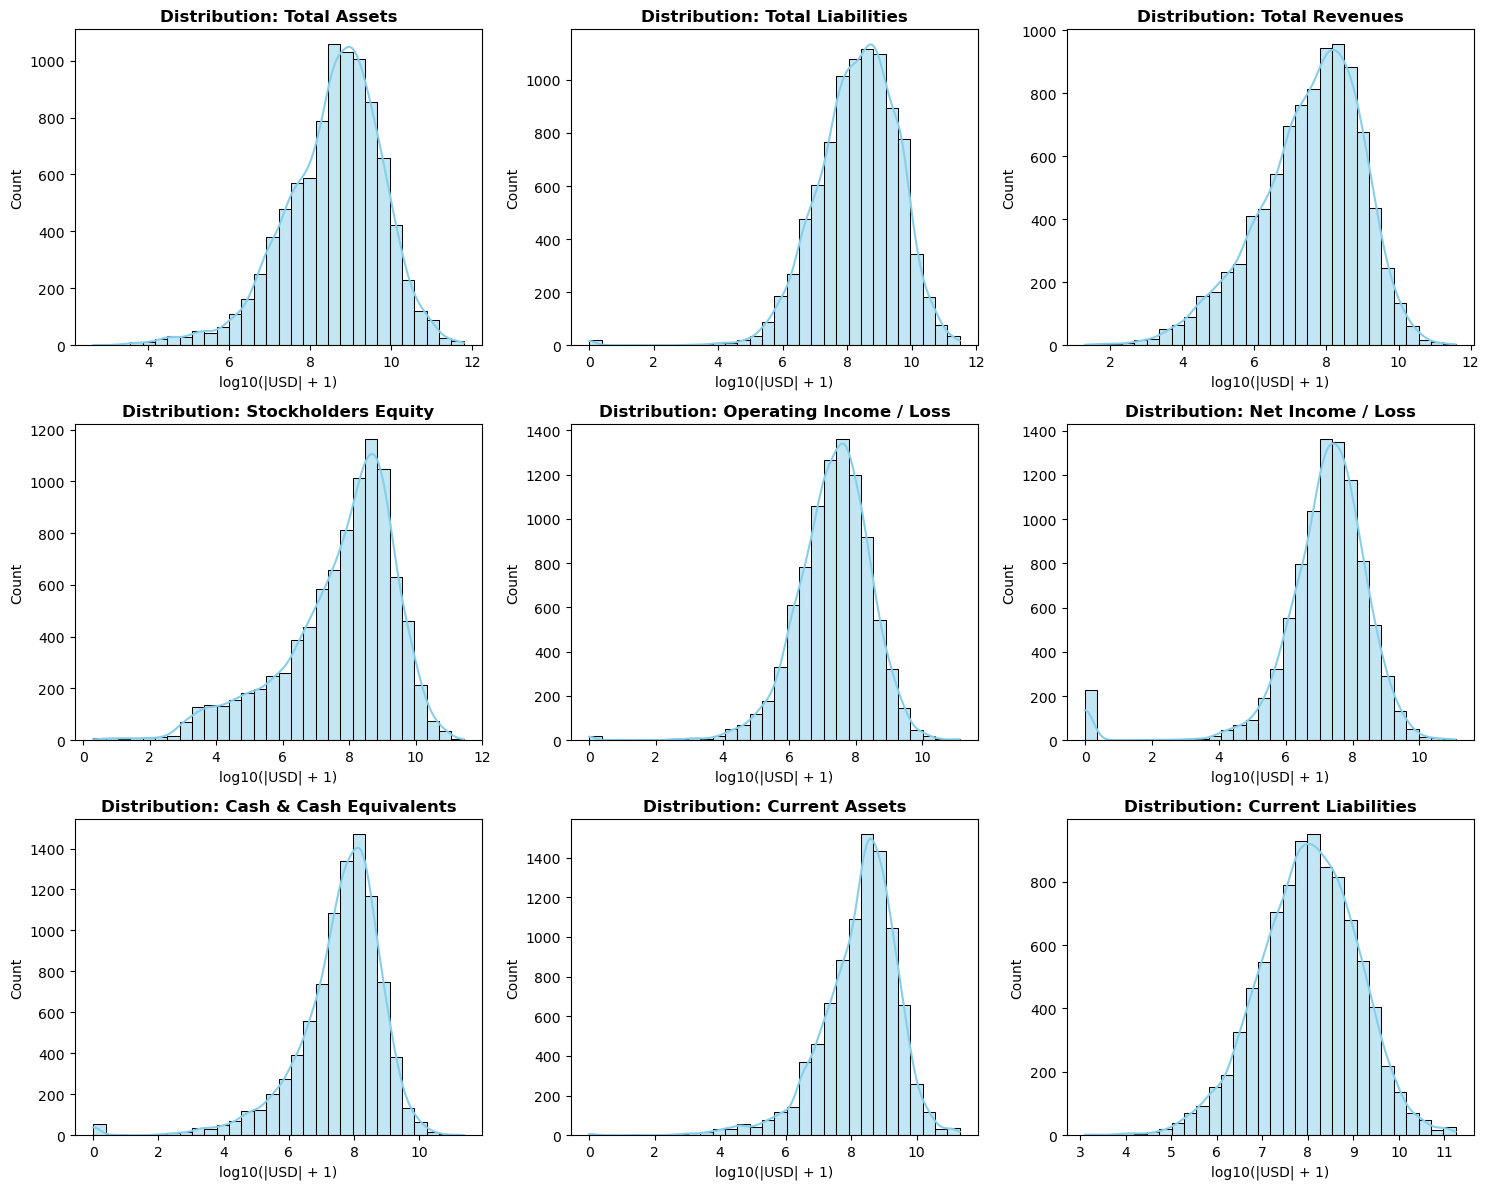

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# For positive values, I use a logarithmic scale on the X-axis
# For variables that can be negative (e.g., NetIncomeLoss), I transform the absolute value

for i, col in enumerate(business_labels):
    data_to_plot = df_features[col]
    label = business_labels[col]

    if (data_to_plot > 0).all():
        sns.histplot(
            data=df_features,
            x=col,
            kde=True,
            ax=axes[i],
            color='skyblue',
            bins=30,
            log_scale=True,
        )
        axes[i].set_xlabel('(USD, Log Scale)')
    else:
        sns.histplot(
            x=np.log10(np.abs(data_to_plot) + 1),
            kde=True,
            ax=axes[i],
            color='skyblue',
            bins=30,
    )
    axes[i].set_xlabel('log10(|USD| + 1)')

    
    axes[i].set_title(f'Distribution: {label}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

Raw positive financial values in USD are typically characterized by extreme right-skewness. After converting these values to **logarithms**, the resulting **distributions were close to normal**. The **median** of most distributions falls within the **range of 7.5–8.5** on the X-axis.

**Most distributions show a gentle decline on the right (large corporations) and a slightly longer tail on the left** (3–6 on the X-axis), indicating the presence of micro-companies or entities in the early stages of development. 

The SEC EDGAR **dataset is dominated by mid-cap and small-cap companies**.

**In some charts** (e.g., the last one in the first row and the first one in the second row), **you can see a vertical bar exactly at the 0 value**. This indicates the presence of entities with a zero value for a given item (e.g., no short-term debt or no revenue in a given quarter).

I created box plots for all the raw financial data.

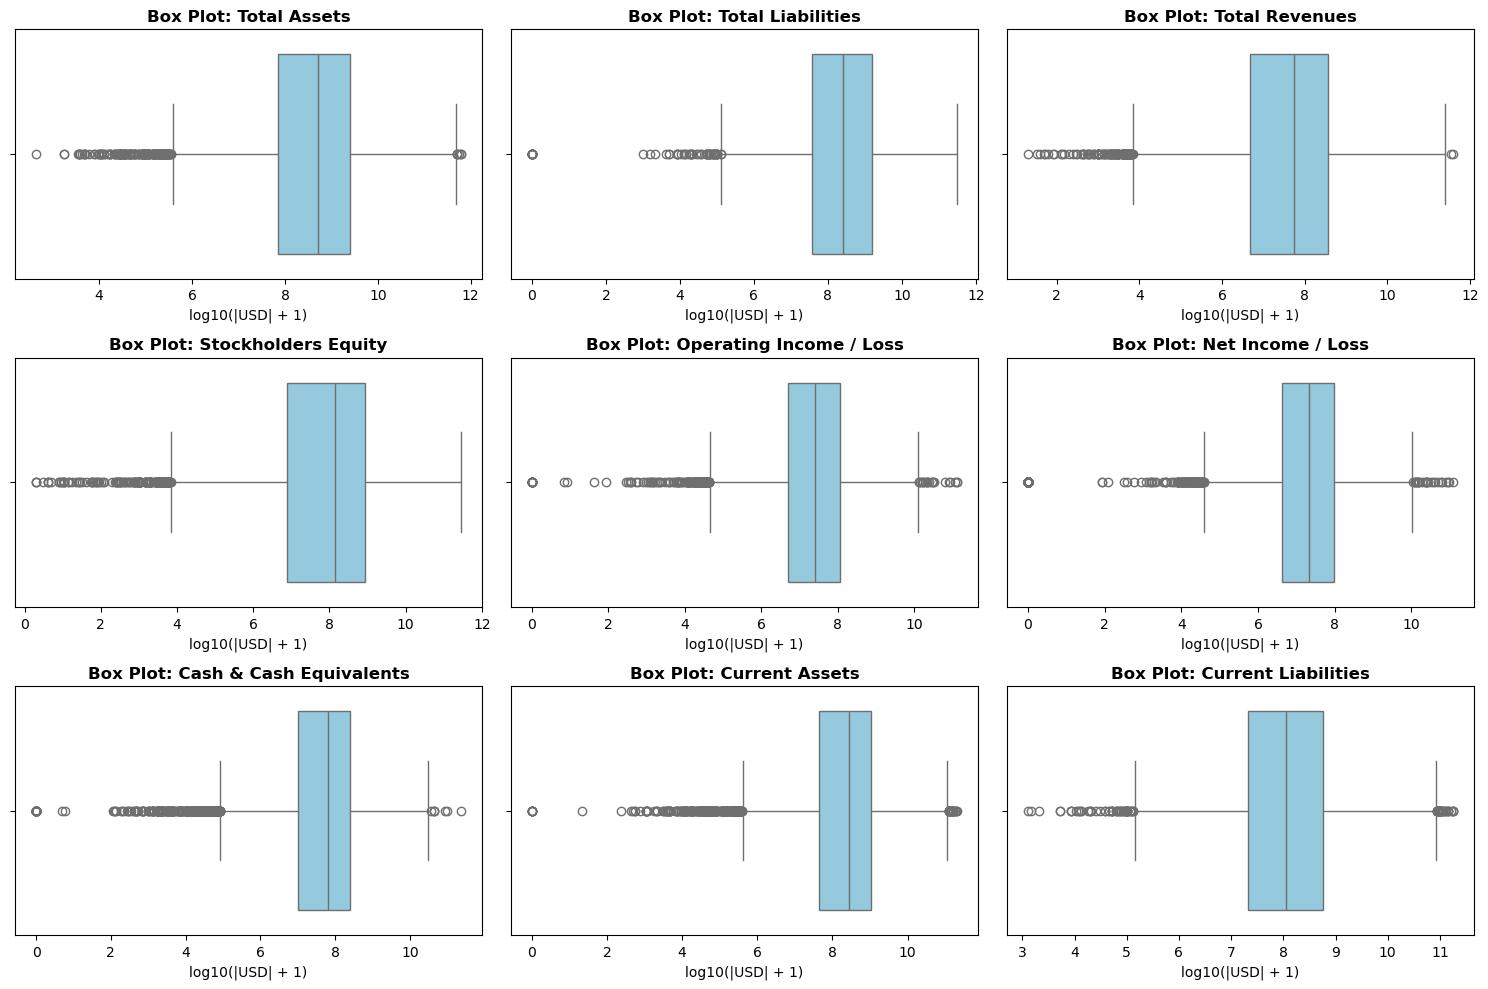

In [41]:
ig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(business_labels):
    label = business_labels[col]
    sns.boxplot(
        x=np.log10(np.abs(df_features[col]) + 1),
        ax=axes[i],
        color='skyblue',
    )
    axes[i].set_title(f'Box Plot: {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('log10(|USD| + 1)')

plt.tight_layout()
plt.show()

**The boxes** (25th–75th percentile range) **for the main balance sheet values** (Total Assets, Current Assets, Total Liabilities) fall within the range of **7.5–9.0 on a logarithmic scale**. **This corresponds to absolute values ranging from 30 million USD to 1 billion USD**. This shows that **the core of the research sample consists of mature mid-cap companies**.

**The boxes for operating and net income are noticeably narrower** (centered around **6.5–8.0**), but show a wide dispersion of data points on both sides. This is due to the fact that for companies teetering on the edge of profitability (with profits close to $0).

In the most box plots upper quartiles and a few max outliers converge around the 11.5–12.0 range, corresponding to approximately 300 billion USD. This establishes a natural ceiling for the largest stock market giants (e.g., mega-cap tech companies).
Most charts show **a large cluster of outliers under lower quartile**.

The SEC EDGAR dataset includes **a large group of companies** with negligible operational scale (e.g., biotech startups in the research phase, special purpose acquisition companies (SPACs), or entities undergoing restructuring) that report assets but **do not generate current revenue**.

## EDA Financial Ratios

Next, I moved on to analyzing the financial ratios.

To clean the data for further analysis, **I applied winsorization**. 

I used this method of data cleaning instead of removing outliers in order to retain rows containing values that exceeded the thresholds I had set. Otherwise, the dataset would have been depleted of companies with extreme risk profiles. 

The results show that the winsorization process effectively cleaned up the dataset—extreme outliers were brought within safe domain limits, and the medians (50%) reflect real market conditions.

In [42]:
# Dictionary defining domain-specific realistic boundaries for financial ratios
clip_bounds = {
    'ROA': (-1.5, 0.5),                       # from -150% to +50%
    'ROE': (-3.0, 3.0),                       # from -300% to +300%
    'operating_margin': (-5.0, 2.0),          # from -500% to +200%
    'current_ratio': (0.0, 10.0),             # Current ratio up to 10
    'debt_to_equity': (-10.0, 15.0),          # from -1000% to 1500%
    'debt_ratio': (0.0, 3.0),                 # from 0 to 300%
    'asset_turnover': (0.0, 5.0),             # Asset turnover ratio up to 5x
    'net_margin': (-5.0, 2.0),                # from -500% to +200%
    'cash_ratio': (0.0, 8.0),                 # Cash ratio up to 8
    'working_capital_to_assets': (-2.0, 1.0)  # from -200% to 100%
}

In [43]:
# I applied winsorization (clipping) to handle extreme outliers
for col, (lower, upper) in clip_bounds.items():
    if col in df_features.columns:
        df_features[col] = df_features[col].clip(lower=lower, upper=upper)

In [44]:
# Verify summary statistics after outlier treatment
print(df_features[list(clip_bounds.keys())].describe().T[['min', '50%', 'max']])

                                 min       50%   max
ROA                        -1.500000 -0.003205   0.5
ROE                        -3.000000  0.002425   3.0
operating_margin           -5.000000 -0.018796   2.0
current_ratio               0.009387  1.870588  10.0
debt_to_equity            -10.000000  0.730801  15.0
debt_ratio                  0.000327  0.567840   3.0
asset_turnover              0.000000  0.122432   5.0
net_margin                 -5.000000 -0.020376   2.0
cash_ratio                  0.000133  0.491224   8.0
working_capital_to_assets  -2.000000  0.205373   1.0


In [45]:
ratio_labels = {
    'ROA': 'ROA',
    'ROE': 'ROE',
    'operating_margin': 'Operating Margin',
    'current_ratio': 'Current Ratio',
    'debt_to_equity': 'Debt to Equity',
    'debt_ratio': 'Debt Ratio',
    'asset_turnover': 'Asset Turnover',
    'net_margin': 'Net Margin',
    'cash_ratio': 'Cash Ratio',
    'working_capital_to_assets': 'Working Capital to Assets'
}

I created histograms for all financial ratios.

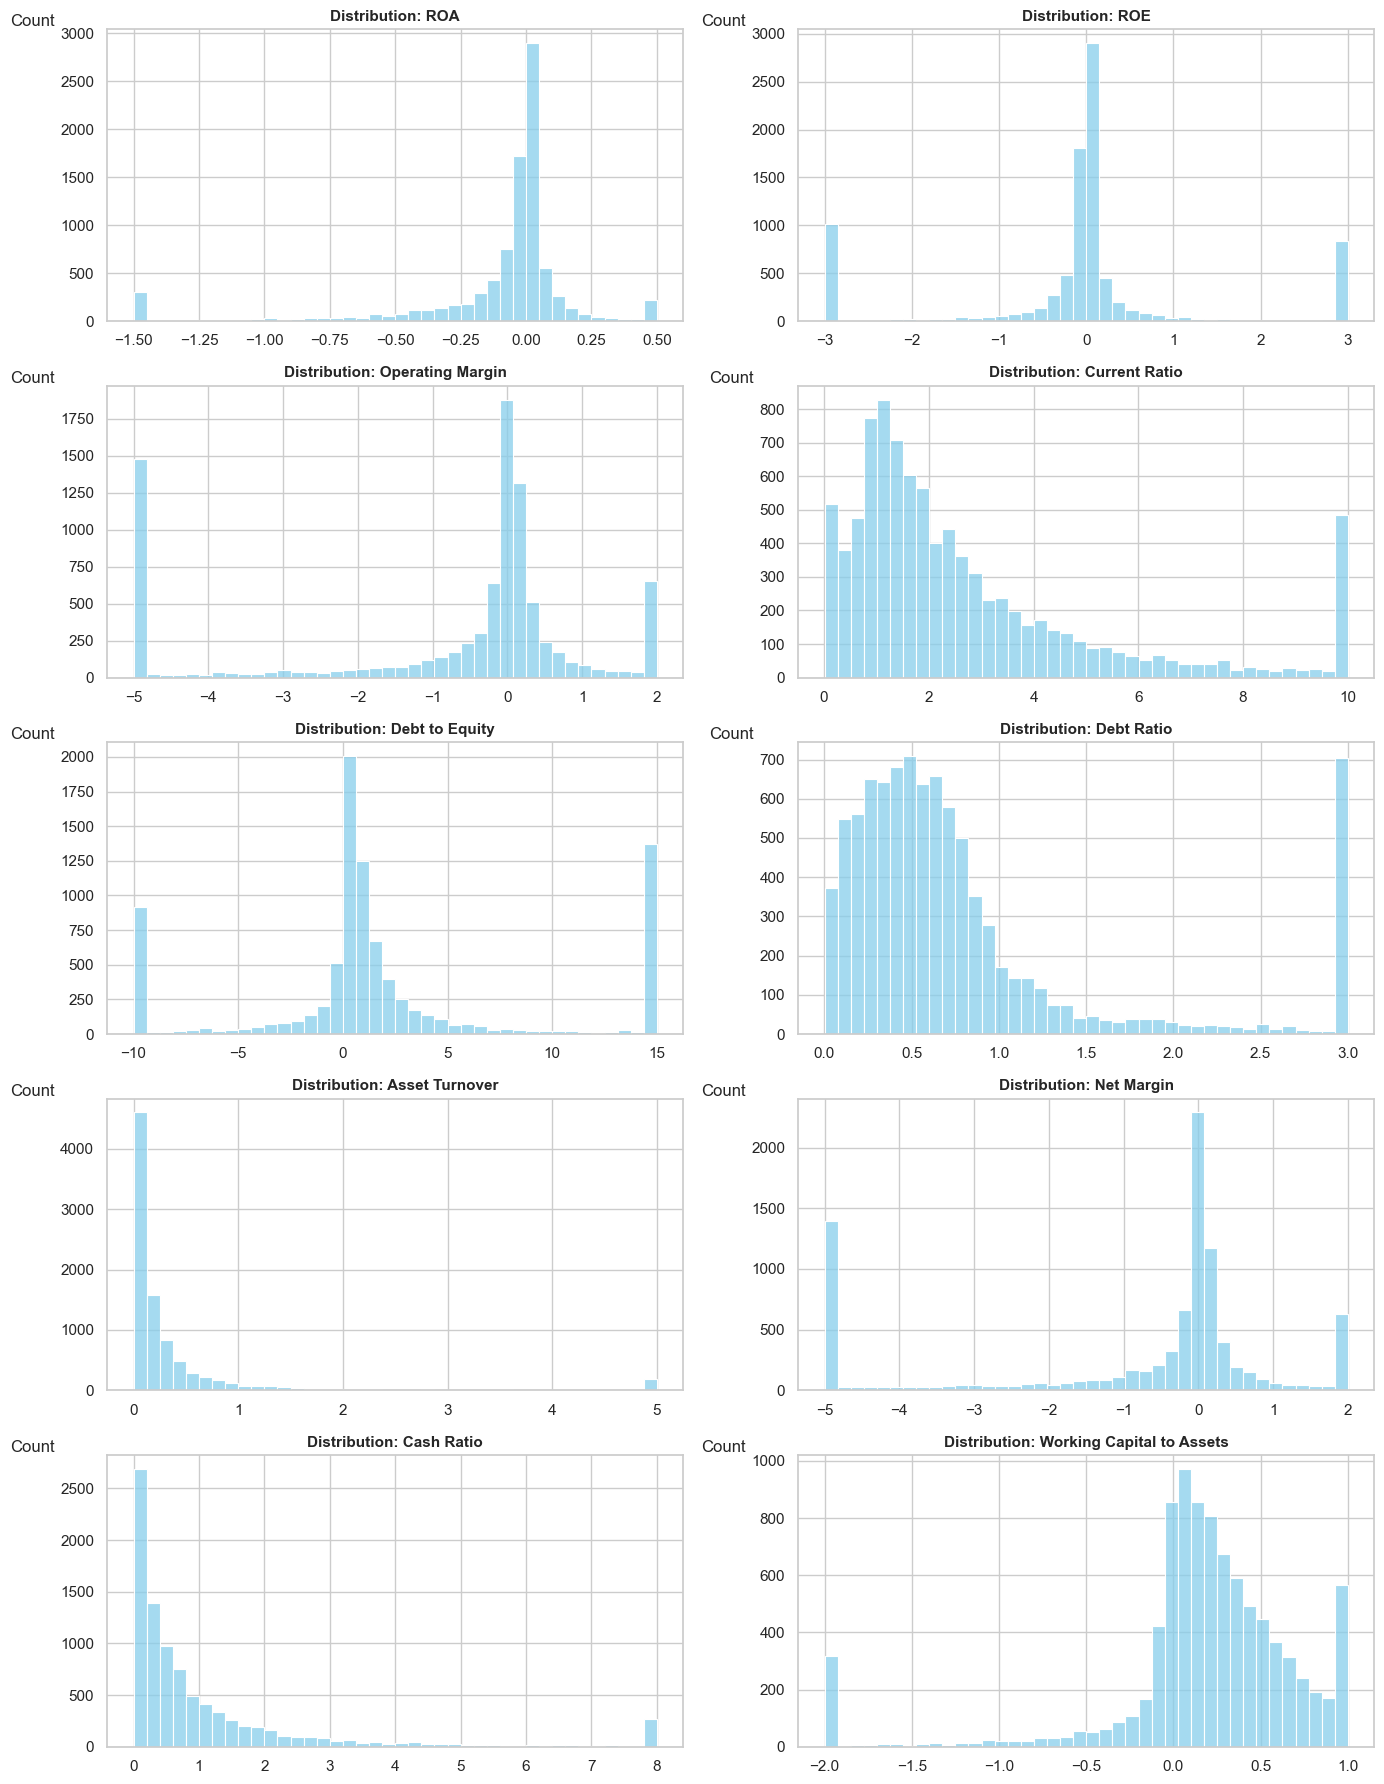

In [88]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(ratio_labels.keys()):
    sns.histplot(data=df_features, x=col, ax=axes[i], color='skyblue', bins=40)
    
  
    clean_title = ratio_labels[col]
    axes[i].set_title(f'Distribution: {clean_title}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', loc="top", rotation=0)

plt.tight_layout()
plt.show()

**1. Profitability Ratios (ROA, ROE, Operating Margin, Net Margin):** 

**The vast majority of companies cluster tightly around 0%**. This confirms a natural market balance between profitable and unprofitable entities.

**There are significant boundary spikes on the far left** (e.g., Operating Margin at -5.0, Net Margin at -5.0, and ROA at -1.5). **This represents a distinct sub-population of financially distressed or early-stage enterprises** (e.g., biotech startups or restructured firms) operating at substantial losses relative to their size.

**All four metrics exhibit strong leptokurtic behavior** (sharp peak near zero with heavy tails), indicating high concentration near baseline performance with notable extreme cases.

**2. Liquidity (Current Ratio, Cash Ratio, Working Capital to Assets) :**

All ratios in this group display **classic right-skewed financial distributions**.

The mode for **Current Ratio** lies **between 1.0 and 2.0**, showing that the majority of companies maintain **adequate short-term liquidity**.

**Working Capital to Assets centers around +0.20**, there is a visible left-hand spike at $2.0. This highlights a subset of companies facing structural short-term working capital deficits.

**3. Capital Structure & Debt (Debt Ratio, Debt to Equity):**

**Debt Ratio** displays a smooth, bell-like distribution centered around 0.57 (57% liabilities to assets ratio), which **represents standard corporate capital leverage**.

The distribution of the **Debt to Equity** shows a strong concentration around **values ranging from 0 to 2**, indicating a **moderate level of debt for most of the companies analyzed**.

**4. Efficiency (Asset Turnover)**:

**Asset Turnover is heavily concentrated under 1.0 (mode around 0.12)**, indicating that capital-intensive firms with large asset bases relative to annual sales dominate the sample.

I created box plots for all financial ratios.

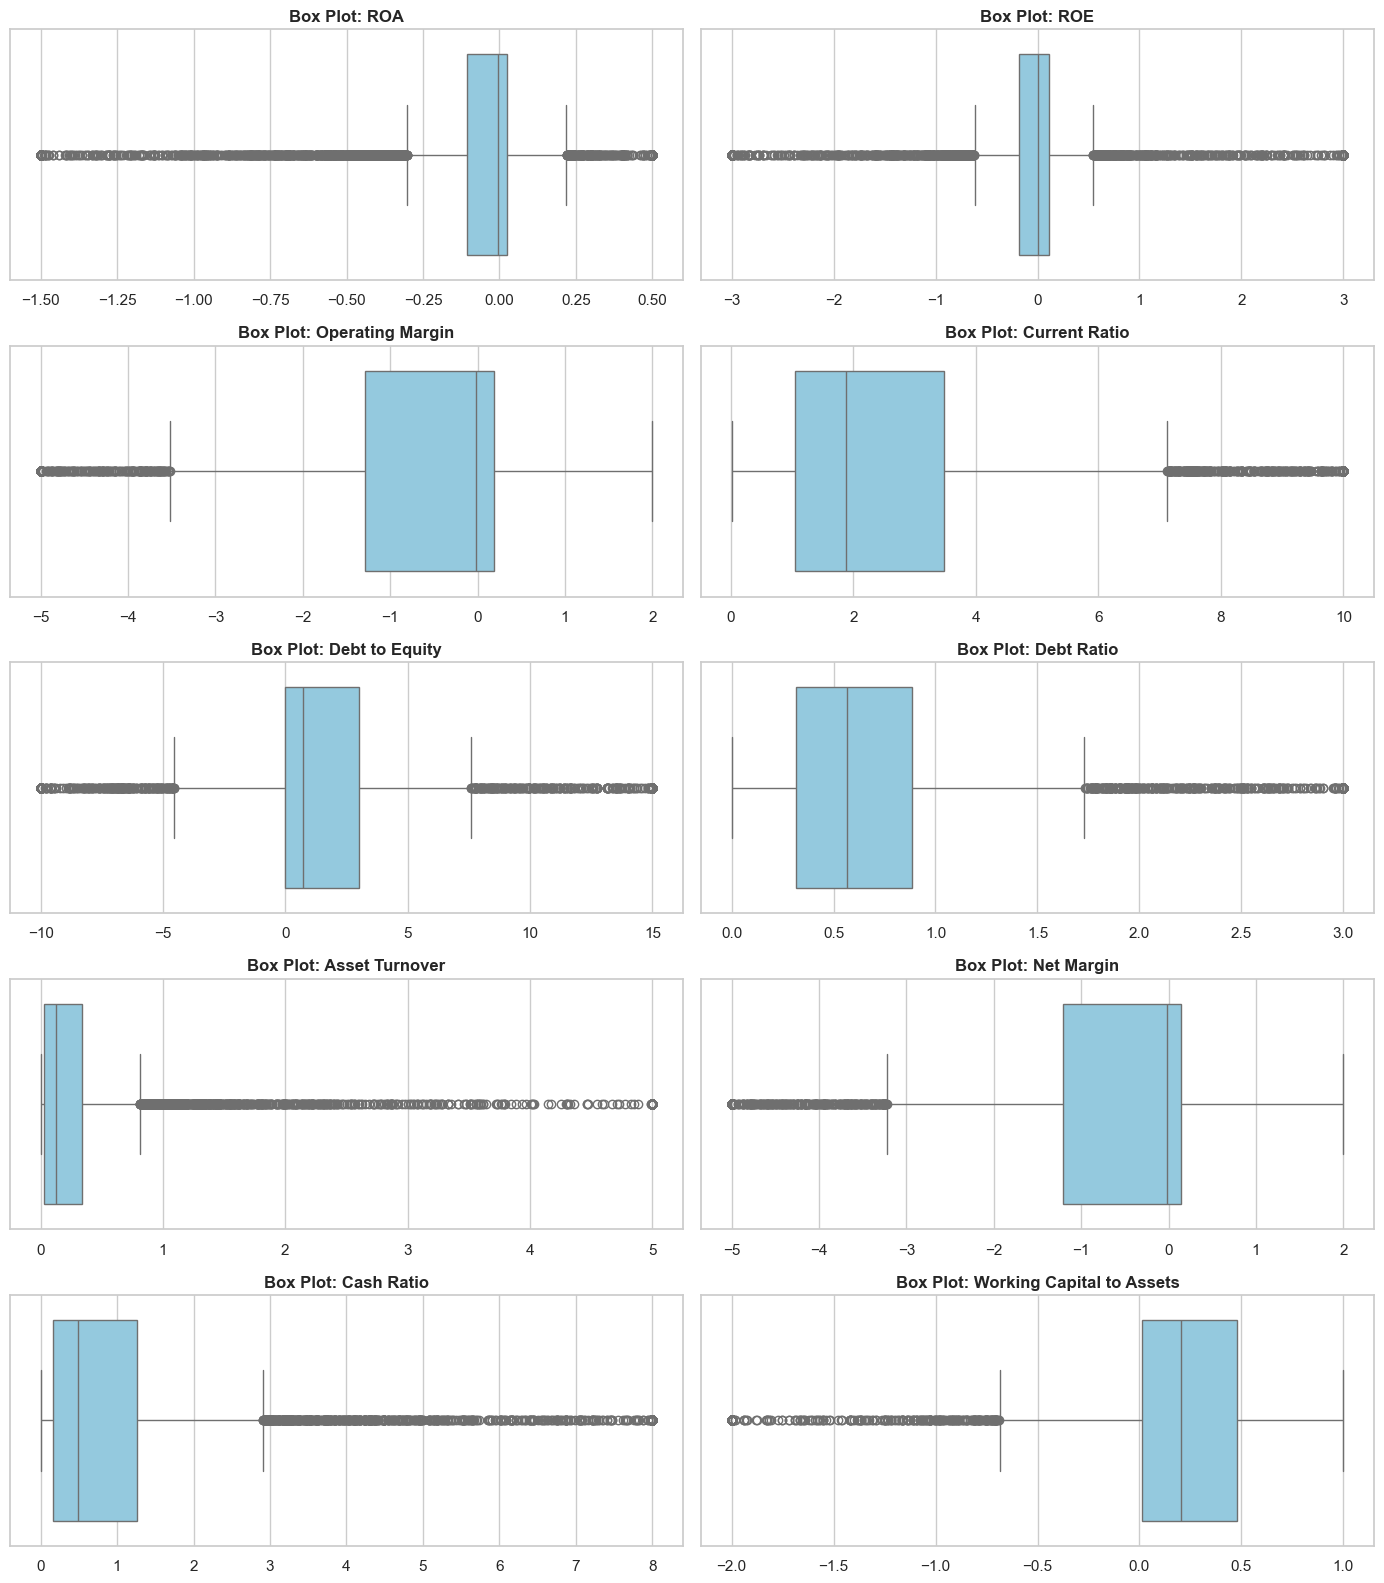

In [47]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(ratio_labels.keys()):
    sns.boxplot(data=df_features, x=col, ax=axes[i], color='skyblue')
    
    clean_title = ratio_labels[col]
    axes[i].set_title(f'Box Plot: {clean_title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [48]:
print(df_features[ratio_cols].describe())

               ROA          ROE  operating_margin  current_ratio  \
count  9097.000000  9097.000000       9097.000000    9097.000000   
mean     -0.112332    -0.076735         -0.873703       2.737874   
std       0.356057     1.429779          2.103272       2.530483   
min      -1.500000    -3.000000         -5.000000       0.009387   
25%      -0.107092    -0.180886         -1.291433       1.047446   
50%      -0.003205     0.002425         -0.018796       1.870588   
75%       0.023198     0.109794          0.191450       3.475423   
max       0.500000     3.000000          2.000000      10.000000   

       debt_to_equity   debt_ratio  asset_turnover   net_margin   cash_ratio  \
count     9097.000000  9097.000000     9097.000000  9097.000000  9097.000000   
mean         2.019571     0.800600        0.395010    -0.866603     1.117109   
std          6.819311     0.781674        0.849619     2.062664     1.696611   
min        -10.000000     0.000327        0.000000    -5.000000    

**1. Profitability (ROA, ROE, Operating Margin, Net Margin):**

**Left-skewed distribution.** The medians of the operating margin (-1.88%) and net margin (-2.04%) are close to zero, while their means (-87.37% and -86.66%) have been significantly skewed downward by negative outliers.

**A large proportion of loss-making companies.** More than half of the companies analyzed report negative operating and net results.

**2. Liquidity (Current Ratio, Cash Ratio, Working Capital to Assets):**

The median **Current Ratio** (1.87) and quick ratio (0.49) indicate a **good overall liquidity position for a typical company**.

Long right-hand “whiskers” on the charts (reaching the threshold values of 10.0 for **Current Ratio** and 8.0 for **Cash Ratio**) suggest the presence of **a large group of technology or biotechnology companies with substantial capital raised from investors**.

**3. Debt (Debt Ratio, Debt to Equity):**

The **Debt to Equity** takes on **negative values** (minimum -10.0), which is a direct **result of negative equity** (accumulated losses from previous years exceed the share capital).

**A typical company finances 56.78% of its assets with debt** (median Debt Ratio = 0.568).

**4. Efficiency (Asset Turnover):**

**Low asset turnover**. The median Asset Turnover is just **0.12**, and the first quartile is 0.028. This indicates a **high proportion of companies in the early stages of development or in the pre-revenue phase** (very low revenue relative to total assets).

Next, I focused on a more detailed analysis of the **OperatingIncomeLoss** column, which will serve as the **target** in the algorithm developed for this project.

**I created a variable “y” that takes the value 1 when OperatingIncomeLoss > 0 (operating income) and the value 0 when OperatingIncomeLoss <= 0 (operating loss / break-even).**

In [49]:
df_features['y'] = (df_features['OperatingIncomeLoss'] > 0).astype(int)

In [50]:
print(f'Operating loss / break-even: {round(df_features['y'].value_counts(normalize=True)[0],2)* 100} %')
print(f'Operating income: {round(df_features['y'].value_counts(normalize=True)[1],2)* 100} %')

Operating loss / break-even: 52.0 %
Operating income: 48.0 %


Since the financial values can be negative and span many orders of magnitude, I used a symmetric logarithmic scale for the scatter plot.

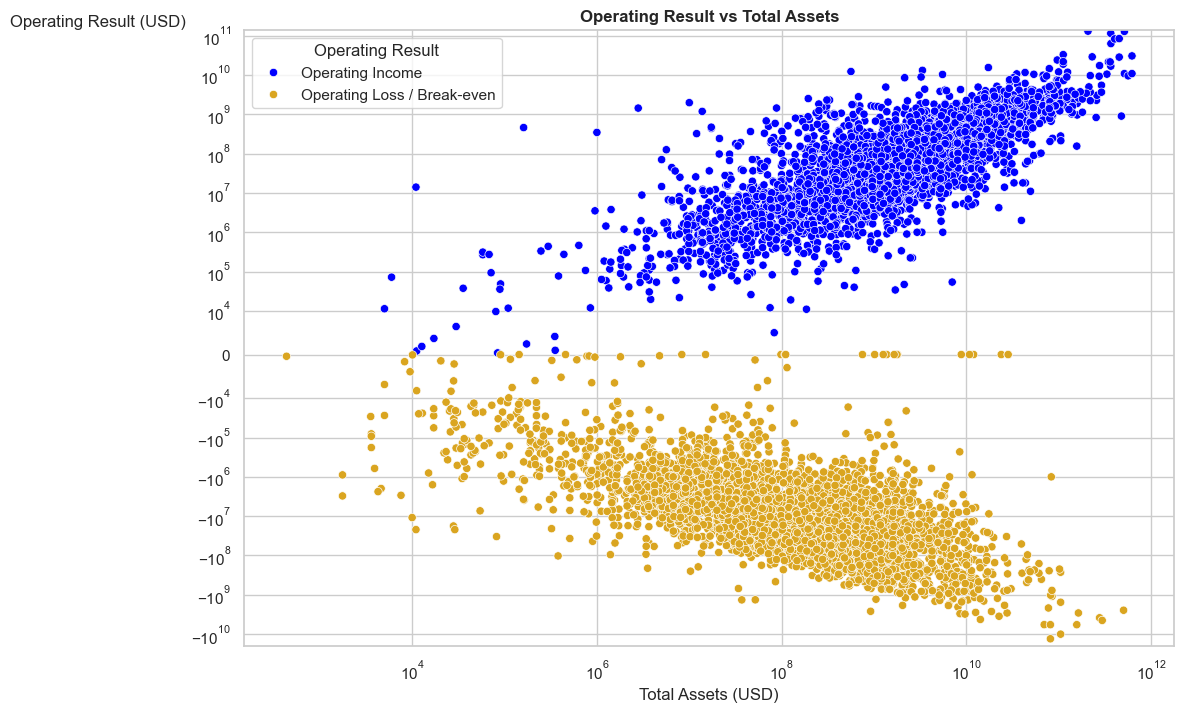

In [51]:
# Map binary target values (0 and 1) to descriptive text labels
y_labels = df_features['y'].map({1: 'Operating Income', 0: 'Operating Loss / Break-even'})

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_features, 
                x='Assets',
                y='OperatingIncomeLoss',
                hue=y_labels,
                palette={'Operating Loss / Break-even': '#DAA520', 'Operating Income': 'blue'})
plt.xscale('log')
plt.yscale('symlog', linthresh=1e4)  # Linear around zero, logarithmic beyond
plt.xlabel('Total Assets (USD)')
plt.ylabel('Operating Result (USD)',loc="top", rotation=0)
plt.title('Operating Result vs Total Assets', fontweight='bold')
plt.legend(title='Operating Result')
plt.show()

**Economies of scale work both ways**. The size of a company’s assets determines the magnitude of its financial results. **Larger assets amplify the absolute scale of results—both profits and losses**.

**Profitable companies show a strong, positive correlation with total assets**. An increase in the scale of operations consistently translates into higher nominal operating profits.

**Large, unprofitable entities generate proportionally higher absolute operating losses than smaller companies**. A large asset base combined with a lack of profitability results in a drastically higher rate of capital “burn”.

**The size of a company's assets does not guarantee profitability**. In the high-asset range, there is a clear bimodality—both highly profitable and heavily loss-making companies are well represented there.

**The horizontal line** of data points at **0** represents entities with a **break-even** or near-zero operating result.

The two-digit prefix of the SIC (Standard Industrial Classification) code allows a company to be unambiguously assigned to a macroeconomic sector (e.g., Manufacturing, Services, Finance). A comparison of the share of profitable companies (y=1) in individual industries reveals structural differences in operating profitability.

In [52]:
# Maps two-digit SIC code prefix to standard macro sectors

def map_sic_to_sector(sic_code): 
    prefix = int(str(sic_code)[:2])
    
    if 1 <= prefix <= 9:
        return 'Agriculture & Forestry'
    elif 10 <= prefix <= 17:
        return 'Mining & Construction'
    elif 20 <= prefix <= 39:
        return 'Manufacturing'
    elif 40 <= prefix <= 49:
        return 'Transportation & Utilities'
    elif 50 <= prefix <= 59:
        return 'Wholesale & Retail Trade'
    elif 60 <= prefix <= 67:
        return 'Finance, Insurance, Real Estate'
    elif 70 <= prefix <= 89:
        return 'Services'
    else:
        return 'Public & Other'

In [53]:
if 'sic' in df_features.columns:
    df_features['sic_sector'] = df_features['sic'].apply(map_sic_to_sector)

    # Calculate share of operationally profitable companies per sector
    sector_stats = (df_features.groupby('sic_sector')['y'].agg(['mean', 'count']).reset_index())
 
    sector_stats = sector_stats[sector_stats['count'] >= 10]  # Filter out minor sectors
    sector_stats = sector_stats.sort_values(by='mean', ascending=False)

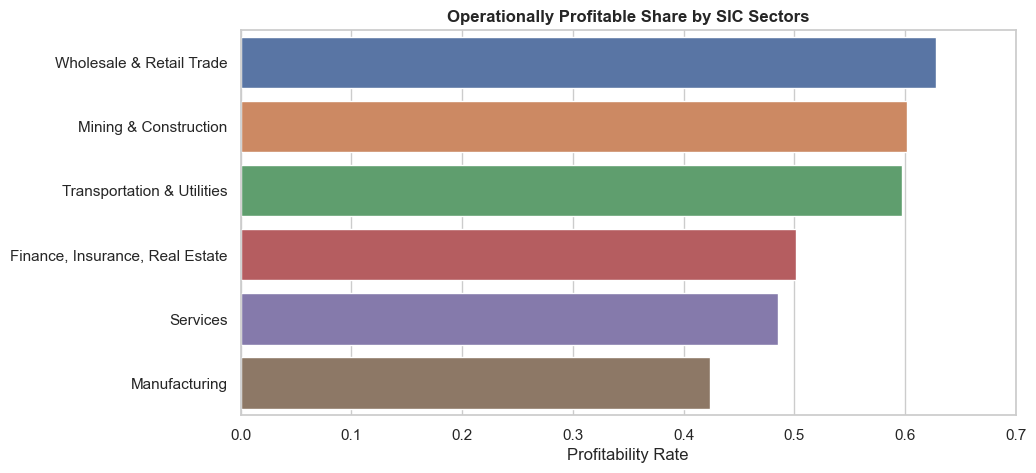

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sector_stats, 
            x='mean', 
            y='sic_sector', 
            hue='sic_sector', 
            legend=False)

plt.title('Operationally Profitable Share by SIC Sectors', fontweight='bold')
plt.xlabel('Profitability Rate')
plt.ylabel(None)
plt.xlim(0, 0.7)
plt.show()

In the context of this analysis, the **Profitability Rate** (operating profitability ratio) **defines the proportion of companies in a given sector that achieve a positive operating result relative to the total number of companies in that SIC sector**. This index takes values in the range (0, 1).

**Wholesale & Retail Trade has the highest profitability ratio (63%)**. This sector is characterized by rapid inventory turnover and the need to generate an immediate sales margin to cover fixed costs.

**The Mining & Construction** and **Transportation & Utilities** sectors **have a high proportion of profitable companies (~60%)**. These are mature, highly capitalized industries with stable cash flows from operating activities.

**The manufacturing** sector has the **lowest operating profitability in the sample (~42%)**, which means that as many as **58% of the analyzed companies are generating an operating loss**. This is due to the large representation of biotechnology, pharmaceutical, and high-tech companies (classified under SIC sections 28 and 38), which incur high research and development (R&D) expenses without generating mass sales.

**Only 48% of companies in the Services sector are operationally profitable**. This sector includes many technology companies (e.g., IT, SaaS software) that, in the early stages of their development, prioritize rapid customer acquisition at the expense of operating profitability.

**In the Finance, Insurance, and Real Estate sector, the proportion of profitable companies is exactly 50%**, which indicates a perfect balance between profitable and unprofitable entities in the sample under study.

In the next step, I moved on to a quarterly analysis of the median operating profit to identify any seasonal trends in the data. I chose the median because of the large number of outliers.

In [55]:
# Set clean visual style
sns.set_theme(style="whitegrid")

# Identify quarterly column or extract from date if needed
quarter_col = next((col for col in ["quarter", "fiscal_quarter", "period", "qtr"]if col in df_features.columns),None,)

quarter_order = ['1Q2025', '2Q2025', '3Q2025', '4Q2025', '1Q2026']

if quarter_col:
  # Aggregate median operating income per quarter
    quarterly_summary = (
        df_features.groupby(quarter_col)["OperatingIncomeLoss"]
        .median()
        .reset_index()
    )

In [56]:
quarterly_summary[quarter_col] = pd.Categorical(
    quarterly_summary[quarter_col], categories=quarter_order, ordered=True
)
quarterly_summary = quarterly_summary.sort_values(quarter_col)

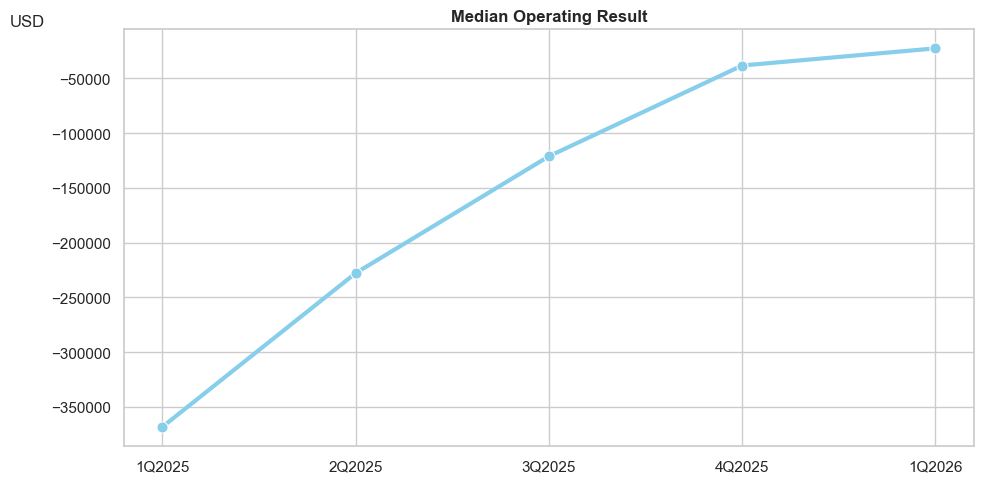

In [57]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=quarterly_summary,
    x=quarter_col,
    y='OperatingIncomeLoss',
    marker='o',
    markersize=8,
    color='skyblue',
   linewidth=3 
)

plt.title('Median Operating Result', fontweight='bold')
plt.xlabel(None)
plt.ylabel('USD', loc='top', rotation=0)
plt.tight_layout()
plt.show()

A clear upward trend in the median operating result was observed in the group of companies under review from 1Q2025 to 1Q2026.

**The median operating result is increasing with each successive quarter**, moving from a deep operating loss of approximately -368,000 USD in 1Q2025 to approximately -24,000 USD in 1Q2026.

Despite the strong upward trend, **the median remains negative throughout the entire time horizon analyzed**.

This is mainly due to the fact that, since 2023, the major U.S. stock indices have been rising, driven by a few of the largest technology companies associated with the AI trend. In contrast, a significant portion of the small- and mid-cap companies included in the stock indices are posting losses or minimal gains. The main cause of this phenomenon is high interest rates, which make it difficult for smaller companies to obtain low-cost loans for growth.

**Important Information:**

**During the transition from exploratory data analysis (EDA) to the construction of the actual predictive model, a deliberate methodological decision was made to exclude the operating margin metric from the set of input features**. The target variable in the model classifies companies as profitable or loss-making. The operating margin is directly based on operating income, which is a key component of final net profit. The goal of the EDA stage is to fully understand the sample's characteristics without imposing strict constraints on the algorithm's input variables. Including operating margin in the EDA allowed us to analyze companies' core operational efficiency prior to accounting for financial and tax expenses.

I used Spearman's rank correlation (which is robust to outliers) to visualize the strength and direction of linear-monotonic relationships between financial ratios and the target column using a heat map.

In [58]:
# Selection of features (without a target variable)
x_features = [
    'current_ratio',
    'cash_ratio',
    'debt_ratio',
    'debt_to_equity',
    'asset_turnover',
    'working_capital_to_assets',
    'ROA',
    'ROE',
    'net_margin',
]

In [59]:
# Calculation the Spearman correlation between the features and OperatingIncomeLoss
corr_target = (
    df_features[x_features + ['OperatingIncomeLoss']]
    .corr(method='spearman')[['OperatingIncomeLoss']]
    .drop(index='OperatingIncomeLoss')
    .sort_values(by='OperatingIncomeLoss', ascending=False)
)

In [60]:
name_mapping = {
    'ROA': 'ROA',
    'net_margin': 'Net Margin',
    'ROE': 'ROE',
    'asset_turnover': 'Asset Turnover',
    'debt_ratio': 'Debt Ratio',
    'debt_to_equity': 'Debt to Equity',
    'current_ratio': 'Current Ratio',
    'working_capital_to_assets': 'Working Capital to Assets',
    'cash_ratio': 'Cash Ratio',
}

corr_target_clean = corr_target.rename(
    index=name_mapping,
    columns={'OperatingIncomeLoss': 'Operating Result'}
)

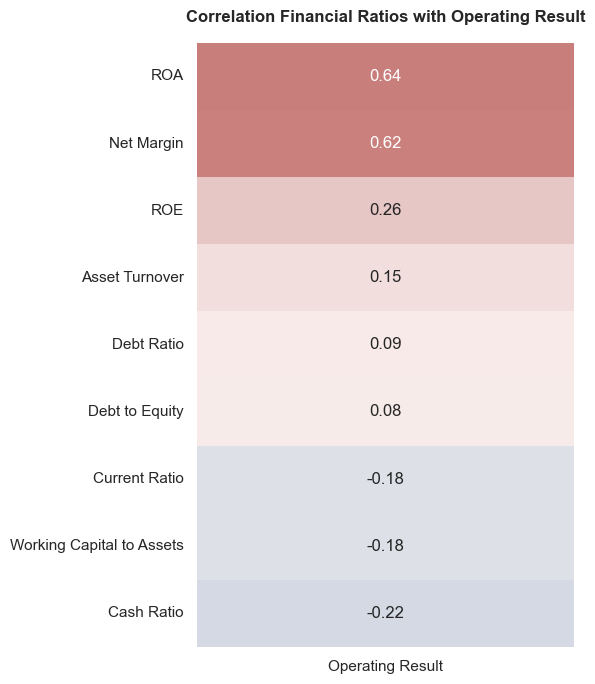

In [61]:
# Visualization in the form of a dedicated heat map
plt.figure(figsize=(6, 7))
sns.heatmap(
    corr_target_clean,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1,
    vmax=1,
    cbar=False
)

plt.title('Correlation Financial Ratios with Operating Result', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**ROA (0.64) and Net Margin (0.62)** show a **strong, positive correlation** with operating profit. Companies with higher return on assets and a high net margin consistently generate higher operating profits.

**ROE (0.26) shows a moderately positive correlation**. The relationship is weaker than that observed for ROA due to distortions resulting from the capital structure (including negative equity among some loss-making entities).

**The correlation coefficient for Asset Turnover is 0.15**. Asset turnover itself **shows only a slight positive relationship** with the level of operating income.

**The Debt Ratio is 0.09 and the Debt to Equity ratio is 0.08**. This indicates that the level of leverage and the debt structure do **not show a direct relationship** with operating profit across the entire sample.

**All liquidity ratios show a negative correlation with operating income**: Cash Ratio (-0.22), Current Ratio (-0.18), and Working Capital to Assets (-0.18). **Young companies** (such as technology or biotechnology firms) **often generate a negative operating result but have high liquidity and cash reserves raised from investors**. In contrast, **mature, profitable companies optimize their working capital and allocate surpluses to investments** rather than maintaining a high level of non-operating cash.

I have only examined the correlation between the variables and the target variable. It is necessary to assess the degree of multicollinearity among the financial indicators themselves to determine whether they convey identical information, which could distort subsequent statistical tests and algorithms.

In [62]:
x_features = [
    'ROA',
    'net_margin',
    'ROE',
    'asset_turnover',
    'debt_ratio',
    'debt_to_equity',
    'current_ratio',
    'working_capital_to_assets',
    'cash_ratio',
]

In [63]:
# Calculation of the Spearman correlation matrix between the variables X
corr_matrix = df_features[x_features].corr(method='spearman')

name_mapping = {
    'ROA': 'ROA',
    'net_margin': 'Net Margin',
    'ROE': 'ROE',
    'asset_turnover': 'Asset Turnover',
    'debt_ratio': 'Debt Ratio',
    'debt_to_equity': 'Debt to Equity',
    'current_ratio': 'Current Ratio',
    'working_capital_to_assets': 'Working Capital to Assets',
    'cash_ratio': 'Cash Ratio',
}

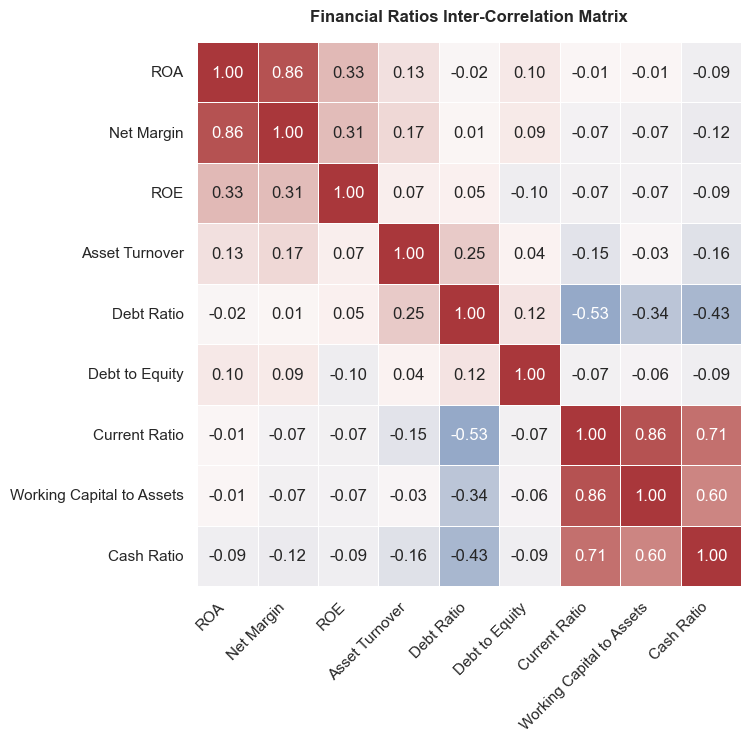

In [64]:
corr_matrix_clean = corr_matrix.rename(index=name_mapping, columns=name_mapping)

plt.figure(figsize=(9, 8))
sns.heatmap(
    corr_matrix_clean,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=False
)

plt.title('Financial Ratios Inter-Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

**Profitability ROA vs. Net Margin (0.86) shows a very strong positive correlation**. An increase in the net margin translates almost directly into an increase in the return on assets in the sample under study.

**The liquidity ratios: Current Ratio vs. Working Capital to Assets (0.86) and Current Ratio vs. Cash Ratio (0.71) show a strong positive correlation**. A high current ratio is strongly associated with a high proportion of working capital and cash.

**The Debt Ratio shows a moderately negative correlation with liquidity ratios**: Current Ratio (-0.53), Cash Ratio (-0.43), and Working Capital to Assets (-0.34). Entities with a higher debt-to-assets ratio have lower liquidity reserves.

**Debt-to-Equity, Asset Turnover, and ROE show weak correlations with all other ratios (r ≤ 0.33)**. They provide a unique insight into capital structure, asset turnover, and returns to shareholders.

**At the end of this section of the project, I compared the distributions of individual indicators separately for profitable companies (y=1) and loss / break-even companies (y=0)**. This serves as a preliminary graphical analysis and justification of the hypotheses for the Mann-Whitney U test.

In [65]:
x_features = [
    'ROA',
    'net_margin',
    'ROE',
    'asset_turnover',
    'debt_ratio',
    'debt_to_equity',
    'current_ratio',
    'working_capital_to_assets',
    'cash_ratio',
]

In [66]:
name_mapping = {
    'ROA': 'ROA',
    'net_margin': 'Net Margin',
    'ROE': 'ROE',
    'asset_turnover': 'Asset Turnover',
    'debt_ratio': 'Debt Ratio',
    'debt_to_equity': 'Debt to Equity',
    'current_ratio': 'Current Ratio',
    'working_capital_to_assets': 'Working Capital to Assets',
    'cash_ratio': 'Cash Ratio',
}

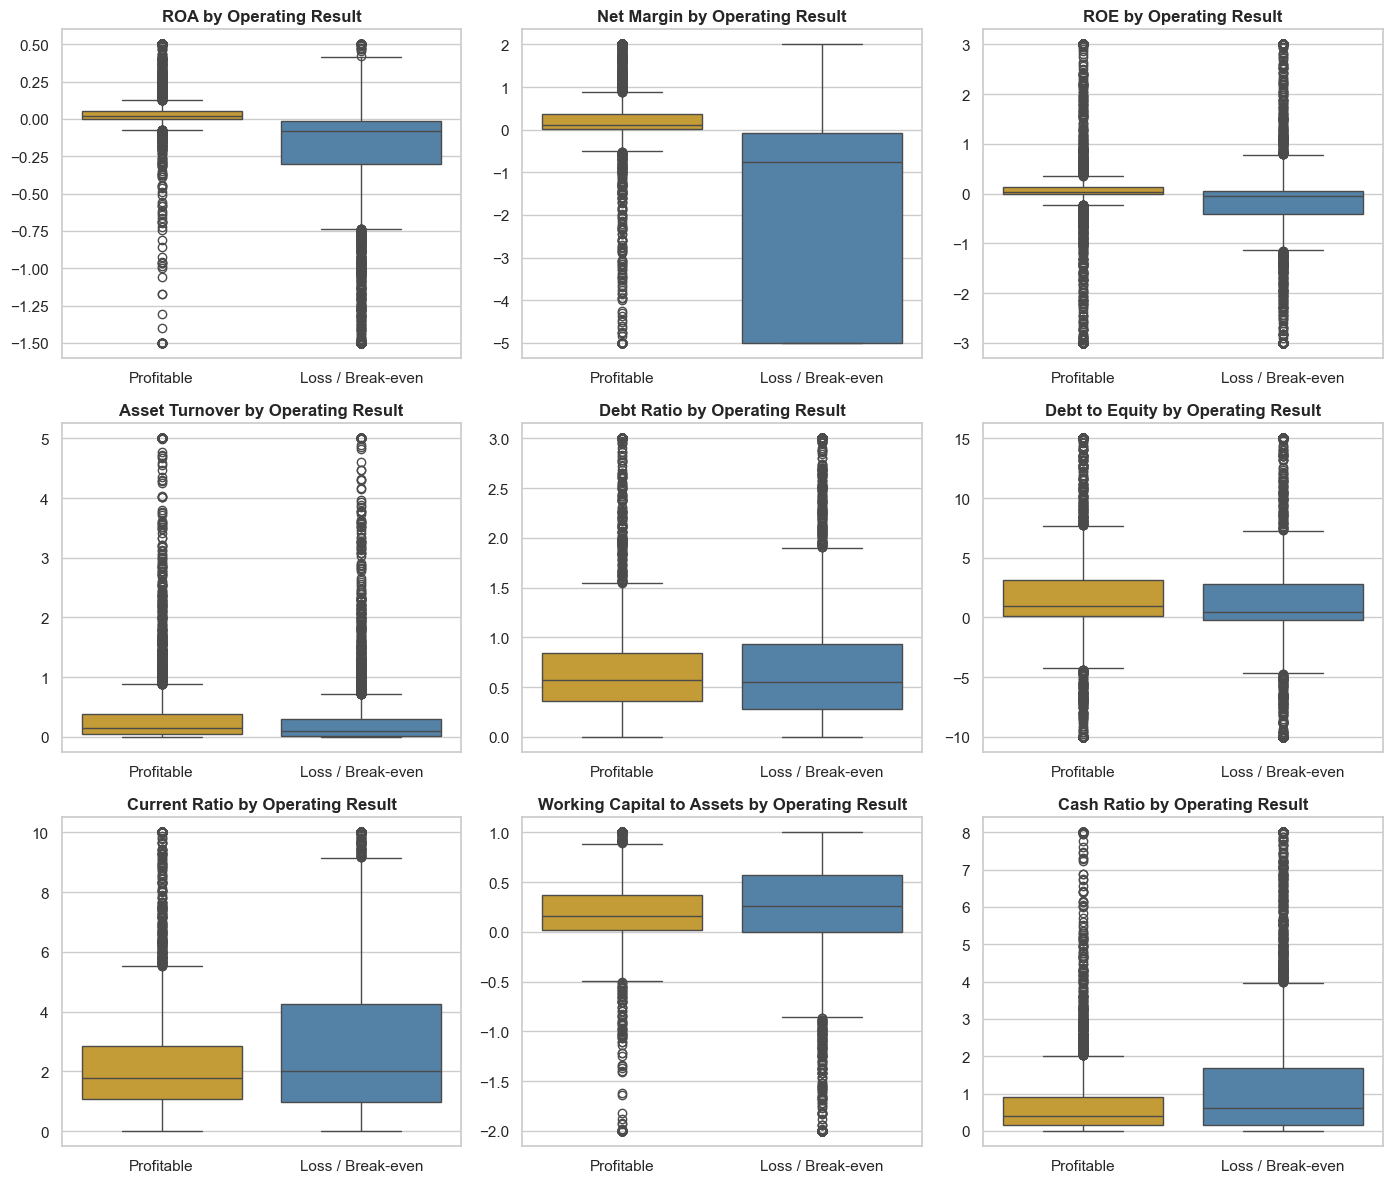

In [67]:
# Creation a copy of the frame with descriptive labels for the variable y
df_plot = df_features.copy()
df_plot['Operating Status'] = df_plot['y'].map(
    {1: 'Profitable', 0: 'Loss / Break-even'}
)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

# Generation boxplots for each feature, grouped by y-classes
for i, feature in enumerate(x_features):

    clean_title = name_mapping.get(feature, feature)

    sns.boxplot(
        data=df_plot,
        x='Operating Status',
        y=feature,
        hue='Operating Status',
        palette=['#DAA520', 'steelblue'],
        ax=axes[i],
        legend=False,
    )
    axes[i].set_title(f'{clean_title} by Operating Result', fontweight='bold')
    axes[i].set_xlabel(None)
    axes[i].set_ylabel(None)

plt.tight_layout()
plt.show()

**ROA and Net Margin are the characteristics with the highest discriminatory power**. The medians for profitable companies are above zero, with a narrow IQR.

**For the Loss / Break-even group, the Net Margin ratio is characterized by extreme volatility** (repeatedly hitting the lower winsor limit of -5.0), which reflects the intense cash burn by companies in the growth phase.

**The ROE distributions show greater overlap due** to distortions resulting from negative equity among some loss-making entities.

**Liquidity Ratios** (Current Ratio, Cash Ratio, Working Capital to Assets). It was observed that **companies in the Loss/Break-even group achieve higher median and upper quartile values** for all three liquidity ratios **than profitable companies**. Loss-making companies (e.g., in the biotechnology or new technology sectors) maintain large cash reserves from funds raised from investors to finance their day-to-day operations. Profitable companies manage their cash more effectively and do not hold excess cash in their accounts.

**The distributions of the Debt Ratio and the Debt to Equity ratio are similar in both groups**. The level of debt leverage alone does not distinguish between profitable and unprofitable companies.

**Asset Turnover is low for both groups** (median values below 0.2), with a slight advantage for profitable companies. 

The distributions differ not only in the location of their medians, but also in their variability and the presence of numerous outliers, which ultimately confirms the need to use nonparametric rank tests instead of parametric tests.

## Exploratory Data Analysis Take-Home Messages:

The dataset is dominated by mature small- and mid-cap companies with total assets ranging between 30M USD and 1B USD.

The sample exhibits strong polarization, spanning from pre-revenue startups to market giants with assets up to $300B.

Return on Assets (ROA) and Net Margin serve as the primary metrics that clearly distinguish profitable firms from unprofitable ones.

ROE and Asset Turnover demonstrate negligible predictive value due to distortions caused by negative equity.

The analysis revealed a market liquidity paradox. Unprofitable companies maintain higher cash reserves to sustain high cash burn rates.

Profitable entities manage working capital more efficiently, deploying financial surpluses into investments rather than holding idle cash.

The trade and construction sectors achieve the highest proportion of profitable firms (>60%), while manufacturing and services are dominated by loss-making entities due to high Research and Development and IT costs.

A large asset base amplifies profits for lucrative companies, but drastically accelerates capital destruction for unprofitable ones.

Despite a gradual recovery in median operating income across 2025–2026, high interest rates continue to prevent smaller companies from reaching profitability.

# Statistical Tests

## Shapiro-Wilk Test

To begin with, I will perform the **Shapiro-Wilk normality test**. This is to ensure that none of the variables are normally distributed and that it is appropriate to use nonparametric tests in the rest of the analysis.

The significance level used in all tests is **α = 0.05**.

**Null hypothesis (H0)**: The distribution of a given variable in the study group follows a normal distribution. 

**Alternative hypothesis (H1)**: The distribution of a given variable significantly deviates from a normal distribution.

In [68]:
x_features = [
    'ROA',
    'net_margin',
    'ROE',
    'asset_turnover',
    'debt_ratio',
    'debt_to_equity',
    'current_ratio',
    'working_capital_to_assets',
    'cash_ratio',
]

In [69]:
shapiro_results = []

for feature in x_features:
    for y_val in [1, 0]:
        group_data = (
        df_features[df_features['y'] == y_val][feature]
        .dropna()
        .sample(100, random_state=42) # I draw a sample of 100 data points. 
    ) # The Shapiro-Wilk test has a strict sample size limit (N ≤ 5000) in the scipy library and distorts the results for large samples.

        stat, p_val = stats.shapiro(group_data)

        shapiro_results.append({
            'Feature': feature,
            'Group (y)': f'Profitable (y={y_val})'
            if y_val == 1
            else f'Loss / Break-even (y={y_val})',
            'W Statistic': round(stat, 4),
            'p-value': f'{p_val:.4e}' if p_val < 0.001 else round(p_val, 4),
            'Normal Distribution (α=0.05)': 'Yes' if p_val >= 0.05 else 'No',
        })

In [70]:
df_shapiro = pd.DataFrame(shapiro_results)
df_shapiro

,Feature,Group (y),W Statistic,p-value,Normal Distribution (α=0.05)
0,ROA,Profitable (y=1),0.5024,8.4256e-17,No
1,ROA,Loss / Break-even (y=0),0.7750,4.5417e-11,No
2,net_margin,Profitable (y=1),0.6873,2.7517e-13,No
3,net_margin,Loss / Break-even (y=0),0.8471,9.3078e-09,No
4,ROE,Profitable (y=1),0.7950,1.7427e-10,No
5,ROE,Loss / Break-even (y=0),0.8389,4.6995e-09,No
6,asset_turnover,Profitable (y=1),0.5484,4.9698e-16,No
7,asset_turnover,Loss / Break-even (y=0),0.4107,3.4172e-18,No
8,debt_ratio,Profitable (y=1),0.7526,1.0942e-11,No
9,debt_ratio,Loss / Break-even (y=0),0.7385,4.6969e-12,No


**The results of the Shapiro-Wilk test clearly indicate that none of the analyzed characteristics follow a normal distribution**. For all variables, both in the group of profitable companies (y=1) and the group of unprofitable companies (y=0), the p-value is significantly lower than the accepted significance level (α = 0.05).

Therefore, in the remainder of this analysis, I will use nonparametric tests to test my hypotheses.

## Mann-Whitney U Test

To determine whether the company’s operating result affects the value of a given financial ratio, **I used the Mann-Whitney U nonparametric test**.

**Null hypothesis (H0)**: The distributions of financial ratios in the group of profitable companies (y = 1) and loss-making companies (y = 0) are identical.

**Alternative hypothesis (H1)**: The distributions of financial ratios in both groups differ from each other (one of the groups exhibits stochastic dominance).

In [71]:
x_features = [
    'ROA',
    'net_margin',
    'ROE',
    'asset_turnover',
    'debt_ratio',
    'debt_to_equity',
    'current_ratio',
    'working_capital_to_assets',
    'cash_ratio',
]

In [72]:
# Division of the set into groups y=1 (Profitable) and y=0 (Loss / Break-even)
group_1 = df_features[df_features['y'] == 1]
group_0 = df_features[df_features['y'] == 0]

In [73]:
results = []

for feature in x_features:
    val_1 = group_1[feature].dropna()
    val_0 = group_0[feature].dropna()

    # Median Values for Assessing the Direction of Differences
    med_1 = val_1.median()
    med_0 = val_0.median()


    # Mann-Whitney U Test (two-tailed alternative hypothesis)
    u_stat, p_val = stats.mannwhitneyu(val_1, val_0, alternative='two-sided')

    results.append({
        'Feature': feature,
        'Median (y=1)': round(med_1, 4),
        'Median (y=0)': round(med_0, 4),
        'U Statistic': round(u_stat, 2),
        'p-value': f'{p_val:.4e}' if p_val < 0.001 else round(p_val, 4),
        'Stat. Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No',
  })

In [74]:
df_mw_results = pd.DataFrame(results).sort_values(by='U Statistic', ascending=False)
df_mw_results

,Feature,Median (y=1),Median (y=0),U Statistic,p-value,Stat. Significant (α=0.05)
0,ROA,0.0180,-0.0835,18100202.0,0.0000e+00,Yes
1,net_margin,0.1014,-0.7672,17829932.5,0.0000e+00,Yes
2,ROE,0.0312,-0.0420,13415847.5,5.7051e-135,Yes
3,asset_turnover,0.1542,0.0930,11892899.0,5.2421e-36,Yes
5,debt_to_equity,0.9954,0.4278,11446983.5,2.6222e-19,Yes
4,debt_ratio,0.5723,0.5565,10610638.0,0.0226,Yes
6,current_ratio,1.7631,2.0270,9501161.5,4.4873e-11,Yes
7,working_capital_to_assets,0.1629,0.2618,9336747.5,2.7584e-15,Yes
8,cash_ratio,0.3967,0.6220,8756946.5,4.8389e-36,Yes


All 9 of the analyzed financial ratios show statistically significant differences (p < 0.05) between profitable companies (y=1) and unprofitable companies (y=0), which **allows us to reject the null hypothesis H0 for each financial ratios**.

**ROA and Net Margin achieved the highest possible p-values** (0.0000e+00) as well as the **highest U-statistics**, making them the strongest predictors of operating result.

A large discrepancy in the **median Net Margin** was observed. The result for **profitable companies was +14.14%**, and for **loss-making companies -76.72%**.

In the case of **liquidity ratios** (Cash Ratio, Working Capital to Assets, Current Ratio), **loss-making companies (y=0) exhibit higher median values**. This result confirms that unprofitable firms maintain larger financial buffers (cash reserves and working capital) to finance negative operating cash flows.

**The median Debt to Equity for profitable companies is more than twice as high**, indicating that profitable companies effectively use debt to generate profits.

**The median Asset Turnover is higher in the group of profitable companies**, which indicates that these companies use their assets more efficiently.

Although the difference in the **Debt Ratio** is statistically significant (p = 0.0226), its **p-value is several orders of magnitude higher than that of the other features**, and the **medians are very close to one another**. It contributes the least unique information to the classification.

## Spearman Correlation

In the previous section of the analysis, I created a visualization of the Spearman correlation coefficients for individual financial ratios. It provided information only on the strength and direction of the relationships among the data under study.

To determine whether there is a monotonic relationship between the indicators under study, I need to conduct Spearman's correlation tests, which will provide me with a p-value.

**Null hypothesis (H0)**: There are no statistically significant monotonic relationships between any pair of characteristics in the matrix of financial coefficients (explanatory variables X).

**Alternative hypothesis (H1)**: There is at least one pair of characteristics in the matrix of financial ratios (explanatory variables X) between which there is a statistically significant monotonic relationship.

In the Spearman correlation tests, a significance level of **α = 0.05** was used.

In [75]:
def spearman_correlation_with_pvalues(df, features):
    
    coef_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
    p_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
    
    for col1 in features:
        for col2 in features:
            if col1 == col2:
                coef_matrix.loc[col1, col2] = 1.0
                p_matrix.loc[col1, col2] = 0.0
            else:
                valid_data = df[[col1, col2]].dropna()
                rho, p_val = stats.spearmanr(valid_data[col1], valid_data[col2])
                coef_matrix.loc[col1, col2] = rho
                p_matrix.loc[col1, col2] = p_val
                
    return coef_matrix, p_matrix

coef_df, p_val_df = spearman_correlation_with_pvalues(df_features, x_features)

print("Spearman's Correlation Coefficient Matrix:")
display(coef_df.round(4))

print("\np-value Matrix:")
display(p_val_df.round(4))

Spearman's Correlation Coefficient Matrix:


,ROA,net_margin,ROE,asset_turnover,debt_ratio,debt_to_equity,current_ratio,working_capital_to_assets,cash_ratio
ROA,1.0000,0.8649,0.3317,0.1340,-0.0248,0.0977,-0.0116,-0.0074,-0.0882
net_margin,0.8649,1.0000,0.3137,0.1732,0.0088,0.0931,-0.0677,-0.0738,-0.1163
ROE,0.3317,0.3137,1.0000,0.0691,0.0480,-0.0951,-0.0734,-0.0691,-0.0875
asset_turnover,0.1340,0.1732,0.0691,1.0000,0.2488,0.0395,-0.1515,-0.0339,-0.1645
debt_ratio,-0.0248,0.0088,0.0480,0.2488,1.0000,0.1211,-0.5308,-0.3403,-0.4346
debt_to_equity,0.0977,0.0931,-0.0951,0.0395,0.1211,1.0000,-0.0726,-0.0566,-0.0928
current_ratio,-0.0116,-0.0677,-0.0734,-0.1515,-0.5308,-0.0726,1.0000,0.8600,0.7092
working_capital_to_assets,-0.0074,-0.0738,-0.0691,-0.0339,-0.3403,-0.0566,0.8600,1.0000,0.5960
cash_ratio,-0.0882,-0.1163,-0.0875,-0.1645,-0.4346,-0.0928,0.7092,0.5960,1.0000



p-value Matrix:


,ROA,net_margin,ROE,asset_turnover,debt_ratio,debt_to_equity,current_ratio,working_capital_to_assets,cash_ratio
ROA,0.0000,0.0000,0.0,0.0000,0.0182,0.0000,0.2669,0.4798,0.0
net_margin,0.0000,0.0000,0.0,0.0000,0.4005,0.0000,0.0000,0.0000,0.0
ROE,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
asset_turnover,0.0000,0.0000,0.0,0.0000,0.0000,0.0002,0.0000,0.0012,0.0
debt_ratio,0.0182,0.4005,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
debt_to_equity,0.0000,0.0000,0.0,0.0002,0.0000,0.0000,0.0000,0.0000,0.0
current_ratio,0.2669,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
working_capital_to_assets,0.4798,0.0000,0.0,0.0012,0.0000,0.0000,0.0000,0.0000,0.0
cash_ratio,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0


Based on the presented p-value matrix, **the null hypothesis is rejected** in favor of the alternative hypothesis.

**There is at least one pair of characteristics in the matrix of financial ratios (explanatory variables X) between which there is a statistically significant monotonic relationship**.

For the vast majority of pairs of characteristics, the p-value is 0.0000. This means that the relationships between these financial indicators are not due to chance and are present throughout the entire population.

**A lack of statistical significance** was observed only for a few specific relationships: 

ROA - working_capital_to_assets (p = 0.4798);

ROA - current_ratio (p = 0.2669);

net_margin - debt_ratio (p = 0.4005).

Although strong interdependencies were identified among certain variables, all explanatory variables are retained in the dataset. Retaining the complete set of financial indicators allows us to preserve the full range of information about the entities under study. The modeling will be performed on the full set of features using algorithms capable of operating effectively in the presence of correlated variables.

## Statistical Tests Take-Home Messages:

The Shapiro-Wilk test indicated a non-normal distribution for all variables, justifying the use of the non-parametric Mann-Whitney U test.

All analyzed financial ratios show statistically significant differences between profitable and unprofitable companies.

ROA and Net Margin proved to be the strongest predictors, revealing a stark contrast in median Net Margin (+14.14% for profitable vs. -76.72% for loss-making firms).

The findings explicitly confirm the market liquidity paradox, demonstrating significantly higher cash reserves in unprofitable companies to finance negative operating cash flows.

Profitable companies demonstrate superior asset management and effective financial leverage, reflected in a median Debt to Equity ratio more than twice as high.

The Debt Ratio contributes the least unique classification value due to highly similar medians in both groups.

The p-value matrix confirmed widespread, statistically significant monotonic relationships across most analyzed variables.

# Machine Learning

## Data Preparation and Preprocessing

When splitting the data into training and test sets, the data must remain in chronological order to prevent data leakage. 

In [76]:
x_features = [
    'ROA',
    'net_margin',
    'ROE',
    'asset_turnover',
    'debt_ratio',
    'debt_to_equity',
    'current_ratio',
    'working_capital_to_assets',
    'cash_ratio',
]

In [77]:
# Extracting the year and quarter from a string
df_temp = df_features.copy()
df_temp['year_temp'] = df_temp['quarter'].str.extract(r'(\d{4})').astype(int)
df_temp['q_temp'] = df_temp['quarter'].str.extract(r'^(\d)').astype(int)

In [78]:
# Sorting data chronologically (year first, then quarter)
df_sorted = df_temp.sort_values(by=['year_temp', 'q_temp']).reset_index(drop=True)

In [79]:
# Division into a training set (70%) and a test set (30%)
split_idx = int(len(df_sorted) * 0.7)

X_train = df_sorted.iloc[:split_idx][x_features]
y_train = df_sorted.iloc[:split_idx]['y']

X_test = df_sorted.iloc[split_idx:][x_features]
y_test = df_sorted.iloc[split_idx:]['y']

print(f'Number of observations - training set (70%): {len(X_train)}')
print(f'Number of observations - test set (30%):   {len(X_test)}')

Number of observations - training set (70%): 6367
Number of observations - test set (30%):   2730


## Model Selection and Hyperparameter Tuning

Of all the algorithms I tested, XGBoost produced the best results. That is why I decided to use it in the final version of my project.

I did not use data scaling in the model because XGBoost is based on a family of decision tree algorithms that do not require data scaling to function properly.

I used hyperparameter tuning to select the best combination of hyperparameters. I split the data into a test set and a validation set, and I saved the test set for last to avoid data leakage.

In [80]:
model = XGBClassifier(random_state=42)

# Defining a grid of hyperparameters to be tested using 5-fold cross-validation
param_grid = {
    'n_estimators': [100,150, 200],
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.01, 0.1],
#    'subsample': [0.1, 0.2 ,0.4],
#    'gamma': [1.5, 2, 3],
#    'min_child_weight': [5, 6, 7],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters found by GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}
0.8401134047189484


I checked the results of all the trained models to see if the hyperparameter values that yielded the best results were outliers, or if there might be even better combinations.

In [81]:
results = pd.DataFrame(grid_search.cv_results_)

param_cols = [
    col for col in results.columns
    if col.startswith("param")
]
results = results[
    param_cols + [
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

results.head()

,param_learning_rate,param_max_depth,param_n_estimators,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
19,0.1,2,150,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.851421,0.006007,0.840113,0.022922,1
22,0.1,3,150,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.869483,0.007061,0.839800,0.023429,2
20,0.1,2,200,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.854052,0.005768,0.839014,0.022542,3
23,0.1,3,200,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.877690,0.005273,0.838701,0.023112,4
18,0.1,2,100,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.845924,0.006206,0.838229,0.023566,5


After limiting the hyperparameters in GridSearchCV to the three main ones that control the model's capacity and learning rate (n_estimators, max_depth, learning_rate), the algorithm's final results improved. Expanding the search grid to include additional regularization parameters (gamma, min_child_weight, subsample) led to overfitting of the cross-validation process to the training data and a deterioration in performance on the chronological test set. Focusing on the three key parameters allowed us to achieve optimal model generalization.

## Model Evaluation

In [82]:
model = grid_search.best_estimator_

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision_0 = precision_score(y_test, y_pred, pos_label=0)
recall_0 = recall_score(y_test, y_pred, pos_label=0)

precision_1 = precision_score(y_test, y_pred, pos_label=1)
recall_1 = recall_score(y_test, y_pred, pos_label=1)

print(f"Accuracy: {accuracy:.4f}\n")

print("Evaluation for the class y = 0:")
print(f"  Precision: {precision_0:.4f}")
print(f"  Recall:    {recall_0:.4f}\n")

print("Evaluation for the class y = 1:")
print(f"  Precision: {precision_1:.4f}")
print(f"  Recall:    {recall_1:.4f}")

Accuracy: 0.8531

Evaluation for the class y = 0:
  Precision: 0.8703
  Recall:    0.8506

Evaluation for the class y = 1:
  Precision: 0.8345
  Recall:    0.8560


**The model correctly classifies over 85% of the observations** in the test set, which confirms its high generalization ability on new, chronologically distinct data.

**The results for both classes are evenly distributed** and fall within a narrow range of 83.5%–87.0%. This indicates that the model is not biased toward either class.

**The precision (87.03%)** indicates that the vast majority of companies identified as **unprofitable** actually are unprofitable. **The sensitivity (85.06%)** means that more than 85% of all unprofitable cases are successfully identified.

The model achieves **high sensitivity (85.60%)** in detecting **profitable** entities, with a **precision of 83.45%**.

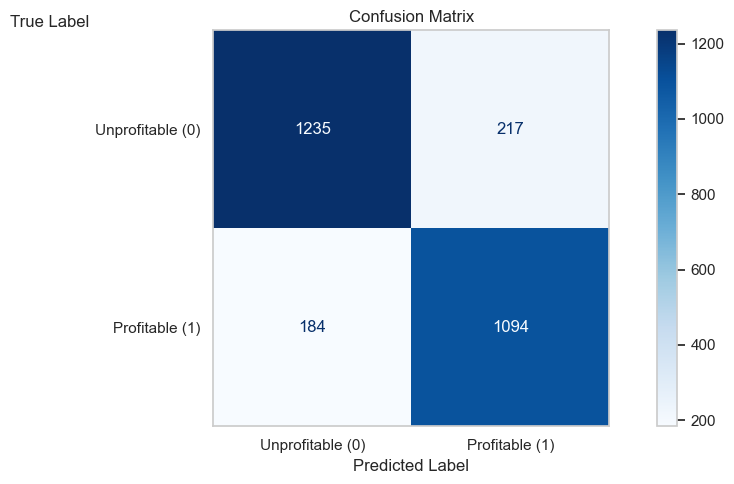

In [83]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Unprofitable (0)", "Profitable (1)"]
)
fig, ax = plt.subplots(figsize=(10, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label", loc='top', rotation=0)
plt.grid(False)
plt.tight_layout()
plt.show()

The model achieves high sensitivity (85.60%) in detecting profitable entities, with a precision of 83.45%. The number of errors of both types is similar and represents a small percentage of the sample, which confirms the model’s balanced performance and the absence of bias toward either class.

## Global Model Interpretability

Finally, I examined the interpretability of my model's decision-making. To do this, I used visualization functions from the shap library.

In [84]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

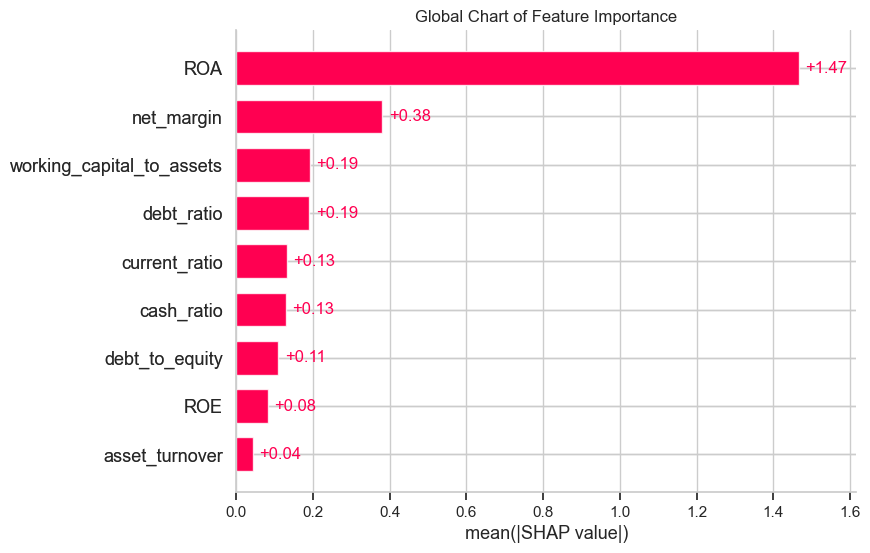

In [85]:
plt.figure(figsize=(10, 6))
plt.title("Global Chart of Feature Importance") 
shap.plots.bar(shap_values, show=False)
plt.show() 

**The ROA ratio is by far the most important feature in the model**. Its impact on the prediction is nearly four times greater than that of the second-ranked ratio, which means that the effectiveness of using assets to generate profit is a key determinant of classification. 

**Net margin** ranks second in importance, serving as a key complement to ROA in assessing sales profitability.

Variables describing working capital (**working capital to_assets**), debt (**debt ratio, debt to equity**), and liquidity (**current ratio**, **cash ratio**) **have a stable, supportive impact on the model’s decisions**, allowing for an adjustment of the assessment in terms of financial risk.

**The ROE and asset turnover ratios contribute the least new information** to the model. ROE’s low ranking stems from the fact that information about return on equity is largely correlated with and captured by ROA and financial leverage ratios.

**Important Information:** 

ROA (Return on Assets) is a measure of asset profitability. The formula is net income divided by total assets. At first, I was afraid that there might be some data leakage from the operating result, but in that case, the ROE (Return on Equity) metric—calculated as net income divided by equity—would also play a significant role in the model’s prediction, and that is not the case. Furthermore, from an accounting perspective, it’s often the case that a company generates an operating profit (i.e., it’s in the black from its core business activities), but after accounting for taxes, dividends, depreciation, and one-time events, it ends up with a net loss. On the other hand, it may also happen that a company reports an operating loss, but in a given year it sold, for example, a factory and, in the final analysis, still ends up with a net profit.



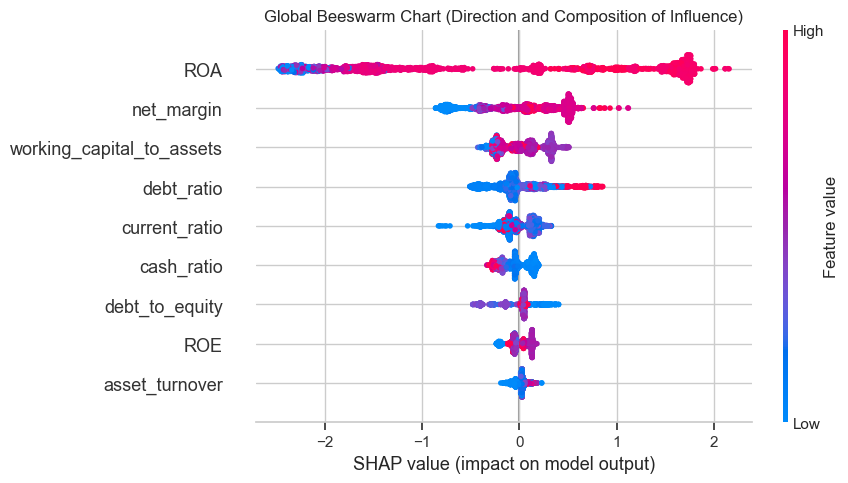

In [86]:
plt.figure(figsize=(10, 6))
plt.title("Global Beeswarm Chart (Direction and Composition of Influence)")
shap.plots.beeswarm(shap_values, show=False)
plt.show()

**The ROA ratio shows the strongest and most unambiguous relationship with the predictive target**. High ROA values (red dot chart on the right) significantly increase the likelihood of a company being classified as profitable (SHAP values range from +1.0 to +2.0). Low values (blue and purple dots on the left) are the strongest signal of unprofitability (SHAP values fall below -2.0).

A higher **net margin** (red dots) consistently increases the likelihood of being classified as “Profitable” (SHAP ranging from +0.2 to +0.9). A low net margin (blue dots) significantly lowers the model's prediction (SHAP ranging from -0.8 to -0.2).

A higher proportion of **working capital to assets** (shades of purple and red) supports the assessment of a company as profitable, highlighting the importance of operating liquidity in evaluating its financial health.

**There is a noticeable imbalance in the debt ratio**. In some cases, a higher level of debt (red points shifted to the right) has a positive effect on the predicted return, which may result from the effective use of financial leverage by well-performing entities.

**Features such as current ratio, cash ratio, debt to equity, ROE, and asset turnover cluster mostly around a SHAP value of 0**. This means that they play only a supporting role in the model, and their extreme values rarely determine the final classification on their own.

Finally, I presented the SHAP Waterfall chart, which explains the prediction for a single company (Instance 0). It shows how the values of financial indicators shifted the starting point to the model’s final result.

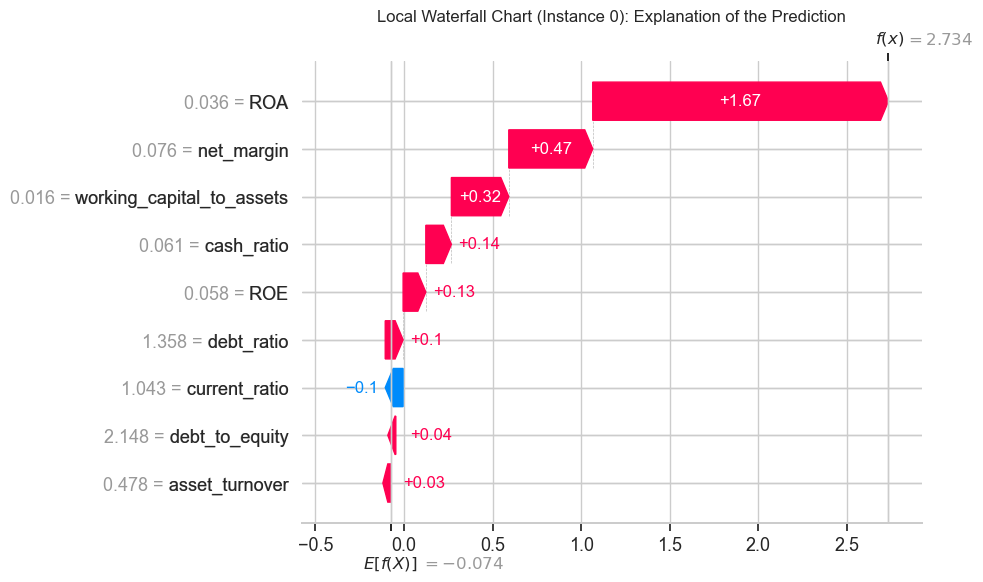

In [87]:
plt.figure(figsize=(10, 6))
plt.title("Local Waterfall Chart (Instance 0): Explanation of the Prediction")
shap.plots.waterfall(shap_values[0], show=False)
plt.show()

**The ROA ratio (0.036) proved to be a key factor in the decision**. It increased the prediction score by as much as +1.67, determining that the entity be classified as a profitable company.

Other key factors that increased the likelihood of a **positive rating** were the **net margin (0.076)**, which rose by +0.47, and the **working capital to assets ratio** (0.016), which rose by +0.32.

**The current ratio (1.043) is the only factor that lowered the score by -0.1**. A value close to 1.0 suggests a relatively low liquidity buffer, which the model interpreted as a minor risk factor.

Features such as the cash ratio, ROE, debt ratio, debt-to-equity ratio, and asset turnover had a small but consistently positive impact on the final forecast.

## Machine Learning Take-Home Messages:

The developed algorithm achieved an accuracy of 85.31% on the chronological test set, demonstrating a balanced sensitivity and precision for both classes.

Limiting the tuning in GridSearchCV to three key hyperparameters (n_estimators, max_depth, learning_rate) prevented overfitting on the cross-validation set and ensured predictive stability.

The SHAP interpretability analysis clearly identified return on assets (ROA) and net margin as the main determinants of financial classification.

Ratios such as ROE and asset turnover had a minimal impact on the model’s decisions.
This suggests that the information contained in these ratios was fully accounted for by ROA, as well as by financial leverage and liquidity ratios.




# Project Summary and Recommendations for Business

**Return on Assets (ROA) is the primary decision-making factor in the developed algorithm**. This is a very interesting observation, since Warren Buffett, the world’s most famous investor, prefers Return on Equity (ROE) in his fundamental analysis of companies. The dominant influence of ROA over ROE in the XGBoost model stems from the mathematical stability of assets, the elimination of distortions resulting from negative equity, and the avoidance of information redundancy in the algorithm. ROA measures the net ability of a company’s assets to generate profit, regardless of whether those assets are financed by debt or equity. ROE is heavily distorted by financial leverage. A company with negligible operating profitability may report a high ROE solely because of its very low level of equity and high debt.

**People involved in selecting publicly traded companies should rely on ROA and Net Margin, which are key indicators of profitability**. The size of a company’s assets alone does not guarantee investment success, as there is a clear divide in the large-cap segment between market leaders and companies that consistently generate losses.

**When analyzing companies, one should be cautious about unprofitable entities** (e.g., technology or biotechnology startups), **which often report high current and quick ratios due to capital raised from investors**. High liquidity in such companies does not reflect financial health, but rather the financing of a rapid rate of cash burn.

**When selecting companies, close attention should be paid to how they utilize debt. The focus should be on stocks of companies capable of effectively converting debt into profit** (as evidenced by a higher Debt to Equity ratio among profitable entities). In contrast, the overall Debt Ratio has low predictive power and should not be treated as a standalone predictor of success. Debt effectively multiplies the profits of financially sound companies, but for unprofitable entities, it drastically accelerates the loss of capital and leads to insolvency.

**Companies that maintain excessive, idle cash reserves should be avoided, as this is typical of loss-making firms funding ongoing "cash burn"**. The key is maintaining a healthy working capital cushion (Working Capital to Assets) and continuously reinvesting financial surpluses.

**A capital allocation strategy should take into account the fact that sectors with high innovation and R&D expenditures** (manufacturing, services) **tend to have lower operating profitability in the early stages of development**, while sectors such as retail, mining and transportation offer more stable, immediate coverage of fixed costs.